# AIM-JEPA GNN + KAN multimodal proof of concept

This notebook trains a graph-based AIM-JEPA-style model on the synthetic AIM-Bio multimodal POC dataset.

The proof of concept keeps the two-stage design from the original notebook:

1. **Target SLD latent pretraining**: train an SLD autoencoder and use its encoder as the frozen structural target encoder.
2. **Graph AIM-JEPA training**: convert each multimodal sample into a fixed-size attributed graph and train a pure PyTorch GNN with KAN-style basis-function layers to predict the frozen SLD latent embedding.

The model predicts latent structural embeddings. It does not train by directly reconstructing raw pixels, raw scattering intensities, or raw SLD profiles. The SLD decoder is used only for diagnostics and visualization.

This is a synthetic method-development benchmark, not biological validation.

This version keeps the GNN+KAN context model and uses configurable KAN bases (`legendre` in the current checked-in configuration, with `fourier`, `chebyshev`, `hermite`, `laguerre`, `gegenbauer`, and `rbf` available) rather than relying on spline packages.


## Graph representation and metrics

Each sample is represented as a graph with:

- 16 scattering q-interval nodes.
- 16 CLSM patch nodes from a 4x4 grid.
- 16 SEM patch nodes from a 4x4 grid.
- 16 q-map patch nodes from a 4x4 grid.
- 1 metadata node.
- 1 global context node.

Edges encode q adjacency, image-patch spatial adjacency, cross-modal patch correspondence, metadata links, and global context links.

The notebook tracks the original AIM-JEPA metrics plus graph/KAN diagnostics: latent cosine/MSE, InfoNCE, SigReg-style Gaussian sketch loss, optional multifractal entropy S(d,q) spectral regularization, predictive cross-spectrum MHE, random-projection variance loss, Recall@1/5/10, median rank, decoded SLD MAE, train-bank retrieved SLD MAE, latent spread/collapse checks, graph edge ablations, node-modality ablations, KAN coefficient statistics, KAN gradient norm, and message-passing embedding norms.


In [36]:
# =====================
# 0. Imports and configuration
# =====================
import os
import math
import json
import time
import random
import platform
import copy
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from IPython.display import display
except Exception:
    display = print

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

RUN_PRESETS = {
    "smoke": {
        "ae_epochs": 1,
        "jepa_epochs": 1,
        "batch_size": 16,
        "hidden_dim": 64,
        "num_gnn_layers": 1,
        "num_basis": 6,
    },
    "short": {
        "ae_epochs": 3,
        "jepa_epochs": 5,
        "batch_size": 16,
        "hidden_dim": 64,
        "num_gnn_layers": 1,
        "num_basis": 6,
    },
    "normal": {
        "ae_epochs": 50,
        "jepa_epochs": 100,
        "batch_size": 32,
        "hidden_dim": 128,
        "num_gnn_layers": 1,
        "num_basis": 8,
    },
}

@dataclass
class Config:
    data_path: str = "/content/aimbio_multimodal_poc_5000.npz"
    output_dir: str = "auto"  # auto -> /content in Colab, local folder otherwise
    run_preset: str = "normal"  # choose smoke, short, or normal
    context_model: str = "gnn_kan"  # default; mlp_baseline is available for comparison
    seed: int = 7
    latent_dim: int = 96
    batch_size: int = 32
    ae_epochs: int = 50
    jepa_epochs: int = 100
    lr_ae: float = 2e-3
    lr_jepa: float = 1e-3
    weight_decay: float = 1e-4
    keep_prob: float = 0.70
    temperature: float = 0.10
    eval_every: int = 1
    num_workers: int = 0
    node_feature_dim: int = 32
    hidden_dim: int = 128
    num_gnn_layers: int = 2
    num_basis: int = 8
    # Supported KAN bases: fourier, chebyshev, legendre, hermite, laguerre, gegenbauer, rbf.
    kan_basis: str = "legendre"
    hermite_variant: str = "probabilists"
    laguerre_alpha: float = 0.0
    gegenbauer_alpha: float = 1.0
    kan_clamp_value: float = 4.0
    dropout: float = 0.10
    lambda_latent: float = 1.0
    lambda_cosine: float = 0.5
    lambda_infonce: float = 0.75
    lambda_sigreg: float = 0.0
    lambda_var: float = 0.5
    lambda_kan_reg: float = 0.0
    # Multifractal entropy S(d,q) / MHE spectral regularizer.
    # Baseline: lambda_mhe=0 and lambda_pred_mhe=0. Add-on: lambda_mhe=0.005 with SIGReg.
    # Replacement: lambda_sigreg=0, lambda_mhe=0.10, lambda_trace=0.05 in the current checked-in run.
    mhe_mode: str = "min_effective_rank"  # min_effective_rank, target_effective_rank, maximize_entropy
    mhe_d_reg: int = 128
    # Entropy betas are beta = mf_d * q. Leave mhe_betas empty to derive them from mf_d and q_values.
    mhe_mf_d: float = 1.0
    mhe_q_values: tuple = (0.5, 1.0, 2.0, 4.0)
    mhe_betas: tuple = ()
    mhe_eps: float = 1e-6
    mhe_use_projection: bool = True
    mhe_r_min_fraction: float = 0.25
    mhe_r_target_fraction: float = 0.25
    mhe_r_min_values: tuple = ()
    mhe_r_target_values: tuple = ()
    mhe_trace_floor: float = -1.0  # auto: 0.5 * min(D_reg, N - 1); set explicitly to override
    lambda_mhe: float = 0.1
    lambda_trace: float = 0.05
    lambda_pred_mhe: float = 0.0
    lambda_pred_trace: float = 0.0
    mhe_compute_every_n_steps: int = 1
    use_masked_node_jepa: bool = True
    lambda_masked_jepa: float = 0.1
    lambda_masked_norm: float = 0.02
    lambda_masked_std: float = 0.02
    lambda_target_norm: float = 0.05
    lambda_target_std: float = 0.05
    ema_tau: float = 0.995
    mask_node_ratio: float = 0.15
    mask_modality_prob: float = 0.2
    mask_metadata_prob: float = 0.05
    sigreg_num_projections: int = 256
    sigreg_target_std: float = 0.8
    collapse_std_threshold: float = 0.01
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


def apply_preset(cfg: Config) -> Config:
    preset = RUN_PRESETS.get(cfg.run_preset)
    if preset is None:
        raise ValueError(f"Unknown run_preset={cfg.run_preset!r}; choose one of {sorted(RUN_PRESETS)}")
    for key, value in preset.items():
        setattr(cfg, key, value)
    return cfg

cfg = apply_preset(Config())

if cfg.output_dir == "auto":
    default_out = Path("/content/aim_jepa_gnn_kan_outputs") if Path("/content").exists() else Path("aim_jepa_gnn_kan_outputs")
    cfg.output_dir = str(default_out)

print(cfg)
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", cfg.device)

if cfg.device == "cpu":
    torch.set_num_threads(min(4, os.cpu_count() or 1))


Config(data_path='/content/aimbio_multimodal_poc_5000.npz', output_dir='/content/aim_jepa_gnn_kan_outputs', run_preset='normal', context_model='gnn_kan', seed=7, latent_dim=96, batch_size=32, ae_epochs=50, jepa_epochs=100, lr_ae=0.002, lr_jepa=0.001, weight_decay=0.0001, keep_prob=0.7, temperature=0.1, eval_every=1, num_workers=0, node_feature_dim=32, hidden_dim=128, num_gnn_layers=1, num_basis=8, kan_basis='legendre', hermite_variant='probabilists', laguerre_alpha=0.0, gegenbauer_alpha=1.0, kan_clamp_value=4.0, dropout=0.1, lambda_latent=1.0, lambda_cosine=0.5, lambda_infonce=0.75, lambda_sigreg=0.0, lambda_var=0.5, lambda_kan_reg=0.0, mhe_mode='min_effective_rank', mhe_d_reg=128, mhe_mf_d=1.0, mhe_q_values=(0.5, 1.0, 2.0, 4.0), mhe_betas=(), mhe_eps=1e-06, mhe_use_projection=True, mhe_r_min_fraction=0.25, mhe_r_target_fraction=0.25, mhe_r_min_values=(), mhe_r_target_values=(), mhe_trace_floor=-1.0, lambda_mhe=0.1, lambda_trace=0.05, lambda_pred_mhe=0.0, lambda_pred_trace=0.0, mhe_com

In [37]:
# =====================
# 1. Load dataset
# =====================

def find_or_upload_dataset(default_path: str) -> Path:
    candidates = [
        Path(default_path),
        Path("/content/aimbio_multimodal_poc_5000.npz"),
        Path("aimbio_multimodal_poc_5000.npz"),
        Path("/mnt/data/aimbio_multimodal_poc_5000.npz"),
    ]
    for p in candidates:
        if p.exists():
            return p

    print("Dataset not found. Please upload aimbio_multimodal_poc_5000.npz.")
    try:
        from google.colab import files
        uploaded = files.upload()
        for name in uploaded.keys():
            if name.endswith(".npz"):
                return Path(name)
    except Exception as exc:
        raise FileNotFoundError(
            "Could not find aimbio_multimodal_poc_5000.npz. Upload it to Colab, "
            "place it beside this notebook, or set cfg.data_path."
        ) from exc

    raise FileNotFoundError("No .npz dataset file was uploaded.")

DATA_PATH = find_or_upload_dataset(cfg.data_path)
print("Using dataset:", DATA_PATH)

npz = np.load(DATA_PATH, allow_pickle=False)
raw = {k: npz[k] for k in npz.files}
npz.close()

print("Arrays:")
for k, v in raw.items():
    print(f"  {k:18s} shape={str(v.shape):18s} dtype={v.dtype}")

required = ["q", "z", "logR_obs", "sld", "clsm", "sem", "qmap", "growth_state", "prep_protocol", "strain_id"]
missing = [k for k in required if k not in raw]
if missing:
    raise KeyError(f"Dataset is missing required arrays: {missing}")


Using dataset: /content/aimbio_multimodal_poc_5000.npz
Arrays:
  q                  shape=(256,)             dtype=float32
  z                  shape=(512,)             dtype=float32
  logR_obs           shape=(5000, 256)        dtype=float32
  logR_true          shape=(5000, 256)        dtype=float32
  sigma_logR         shape=(5000, 256)        dtype=float32
  sld                shape=(5000, 512)        dtype=float32
  n_layers           shape=(5000,)            dtype=int64
  layer_d            shape=(5000, 3)          dtype=float32
  layer_rho          shape=(5000, 3)          dtype=float32
  interface_sigma    shape=(5000, 4)          dtype=float32
  substrate_rho      shape=(5000,)            dtype=float32
  scale              shape=(5000,)            dtype=float32
  background         shape=(5000,)            dtype=float32
  meta_json          shape=()                 dtype=<U497
  source_index       shape=(5000,)            dtype=int64
  clsm               shape=(5000, 2, 64, 64

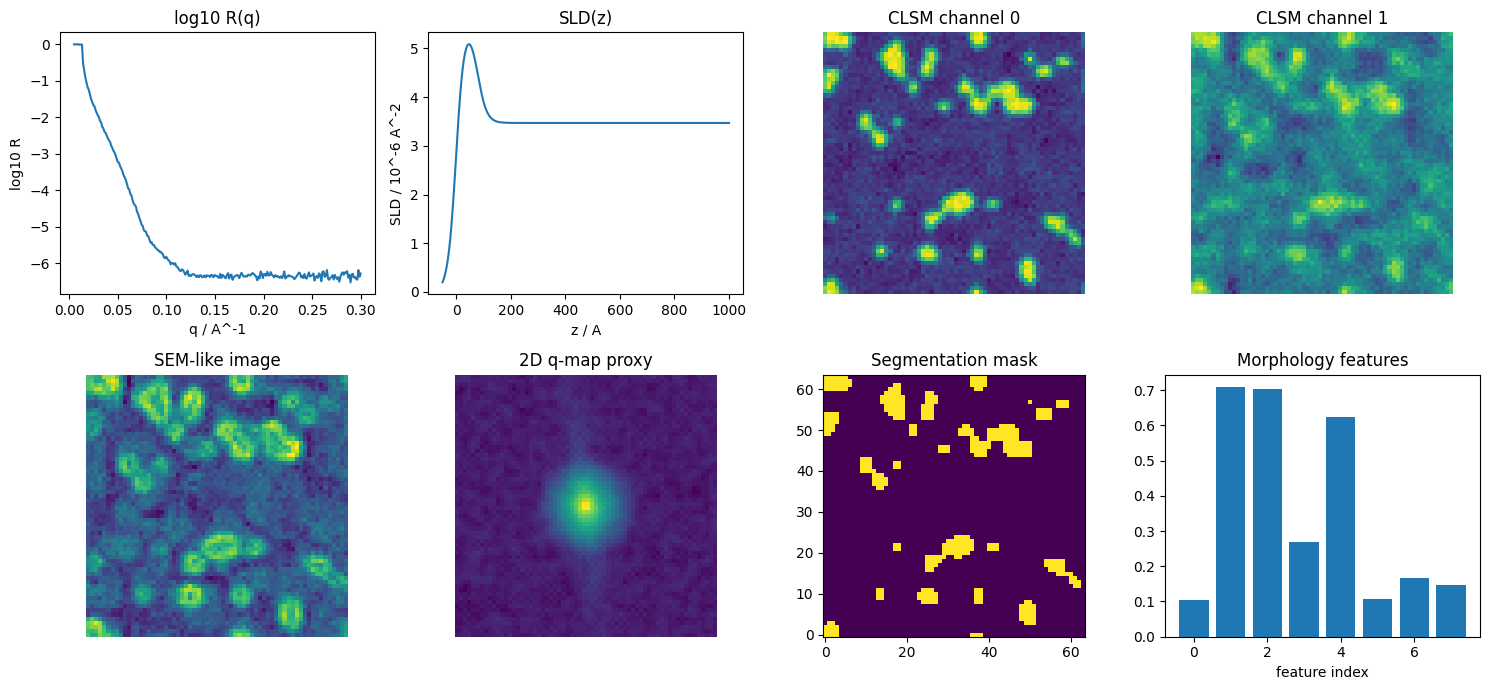

In [38]:
# =====================
# 2. Quick data visualization
# =====================

i = 0
q = raw["q"]
z_grid = raw["z"]

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes[0, 0].plot(q, raw["logR_obs"][i])
axes[0, 0].set_title("log10 R(q)")
axes[0, 0].set_xlabel("q / A^-1")
axes[0, 0].set_ylabel("log10 R")

axes[0, 1].plot(z_grid, raw["sld"][i] * 1e6)
axes[0, 1].set_title("SLD(z)")
axes[0, 1].set_xlabel("z / A")
axes[0, 1].set_ylabel("SLD / 10^-6 A^-2")

axes[0, 2].imshow(raw["clsm"][i, 0], origin="lower")
axes[0, 2].set_title("CLSM channel 0")
axes[0, 2].axis("off")

axes[0, 3].imshow(raw["clsm"][i, 1], origin="lower")
axes[0, 3].set_title("CLSM channel 1")
axes[0, 3].axis("off")

axes[1, 0].imshow(raw["sem"][i, 0], origin="lower")
axes[1, 0].set_title("SEM-like image")
axes[1, 0].axis("off")

axes[1, 1].imshow(raw["qmap"][i, 0], origin="lower")
axes[1, 1].set_title("2D q-map proxy")
axes[1, 1].axis("off")

if "mask" in raw:
    axes[1, 2].imshow(raw["mask"][i], origin="lower")
    axes[1, 2].set_title("Segmentation mask")
else:
    axes[1, 2].axis("off")

if "morph_features" in raw:
    axes[1, 3].bar(np.arange(raw["morph_features"].shape[1]), raw["morph_features"][i])
    axes[1, 3].set_title("Morphology features")
    axes[1, 3].set_xlabel("feature index")
else:
    axes[1, 3].axis("off")

plt.tight_layout()
plt.show()


In [39]:
# =====================
# 3. Split, normalization, and dataset wrapper
# =====================

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

N = raw["logR_obs"].shape[0]
indices = np.arange(N)
rng = np.random.default_rng(cfg.seed)
rng.shuffle(indices)

n_train = int(0.70 * N)
n_val = int(0.15 * N)
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]
print(f"N={N}, train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")


def mean_std(arr, idx, axes=None, eps=1e-6):
    x = arr[idx].astype(np.float32)
    if axes is None:
        m = float(x.mean())
        s = float(x.std())
    else:
        m = x.mean(axis=axes, keepdims=True).astype(np.float32)
        s = x.std(axis=axes, keepdims=True).astype(np.float32)
    return m, np.maximum(s, eps)

stats = {}
stats["logR_mean"], stats["logR_std"] = mean_std(raw["logR_obs"], train_idx)
if "sigma_logR" in raw:
    stats["sigma_mean"], stats["sigma_std"] = mean_std(raw["sigma_logR"], train_idx)
else:
    stats["sigma_mean"], stats["sigma_std"] = 0.0, 1.0
stats["sld_mean"], stats["sld_std"] = mean_std(raw["sld"], train_idx)
if "morph_features" in raw:
    stats["morph_mean"], stats["morph_std"] = mean_std(raw["morph_features"], train_idx, axes=0)
else:
    stats["morph_mean"] = np.zeros((1, 8), dtype=np.float32)
    stats["morph_std"] = np.ones((1, 8), dtype=np.float32)
stats["q_min"] = float(raw["q"].min())
stats["q_max"] = float(raw["q"].max())

print("Normalization stats:")
for k, v in stats.items():
    if np.ndim(v) == 0:
        print(f"  {k:12s}: {float(v):.6g}")
    else:
        print(f"  {k:12s}: shape={v.shape}")

class AIMBioGraphPocDataset(Dataset):
    """Returns normalized multimodal tensors. The true SLD is returned only as target/diagnostic data."""
    def __init__(self, raw_arrays, indices, stats):
        self.raw = raw_arrays
        self.indices = np.asarray(indices)
        self.stats = stats
        q = self.raw["q"].astype(np.float32)
        self.q_norm = ((q - stats["q_min"]) / (stats["q_max"] - stats["q_min"] + 1e-12)).astype(np.float32)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        j = int(self.indices[i])

        logR = self.raw["logR_obs"][j].astype(np.float32)
        logR_n = (logR - self.stats["logR_mean"]) / self.stats["logR_std"]
        if "sigma_logR" in self.raw:
            sig = self.raw["sigma_logR"][j].astype(np.float32)
            sig_n = (sig - self.stats["sigma_mean"]) / self.stats["sigma_std"]
        else:
            sig_n = np.zeros_like(logR_n, dtype=np.float32)
        curve = np.stack([self.q_norm, logR_n, sig_n], axis=0).astype(np.float32)

        sld_raw = self.raw["sld"][j].astype(np.float32)
        sld = ((sld_raw - self.stats["sld_mean"]) / self.stats["sld_std"]).astype(np.float32)[None, :]

        if "morph_features" in self.raw:
            morph = self.raw["morph_features"][j].astype(np.float32)
            morph = ((morph - self.stats["morph_mean"].squeeze()) / self.stats["morph_std"].squeeze()).astype(np.float32)
        else:
            morph = np.zeros(8, dtype=np.float32)

        return {
            "curve": torch.from_numpy(curve),
            "sld": torch.from_numpy(sld),
            "sld_raw": torch.from_numpy(sld_raw),
            "clsm": torch.from_numpy(self.raw["clsm"][j].astype(np.float32)),
            "sem": torch.from_numpy(self.raw["sem"][j].astype(np.float32)),
            "qmap": torch.from_numpy(self.raw["qmap"][j].astype(np.float32)),
            "morph": torch.from_numpy(morph),
            "growth": torch.tensor(int(self.raw["growth_state"][j]), dtype=torch.long),
            "prep": torch.tensor(int(self.raw["prep_protocol"][j]), dtype=torch.long),
            "strain": torch.tensor(int(self.raw["strain_id"][j]), dtype=torch.long),
            "index": torch.tensor(j, dtype=torch.long),
        }

train_ds = AIMBioGraphPocDataset(raw, train_idx, stats)
val_ds = AIMBioGraphPocDataset(raw, val_idx, stats)
test_ds = AIMBioGraphPocDataset(raw, test_idx, stats)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=(cfg.device == "cuda"))
train_eval_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=(cfg.device == "cuda"))
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=(cfg.device == "cuda"))
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=(cfg.device == "cuda"))

batch = next(iter(train_loader))
print({k: tuple(v.shape) for k, v in batch.items() if torch.is_tensor(v)})


N=5000, train=3500, val=750, test=750
Normalization stats:
  logR_mean   : -5.51994
  logR_std    : 2.08184
  sigma_mean  : 0.0444776
  sigma_std   : 0.0223465
  sld_mean    : 3.74842e-06
  sld_std     : 1.94518e-06
  morph_mean  : shape=(1, 8)
  morph_std   : shape=(1, 8)
  q_min       : 0.005
  q_max       : 0.3
{'curve': (32, 3, 256), 'sld': (32, 1, 512), 'sld_raw': (32, 512), 'clsm': (32, 2, 64, 64), 'sem': (32, 1, 64, 64), 'qmap': (32, 1, 64, 64), 'morph': (32, 8), 'growth': (32,), 'prep': (32,), 'strain': (32,), 'index': (32,)}


In [40]:
# =====================
# 4. Fixed graph specification
# =====================

NODE_TYPES = ["scattering", "clsm", "sem", "qmap", "metadata", "global"]
EDGE_TYPES = [
    "q_adj",
    "spatial_clsm",
    "spatial_sem",
    "spatial_qmap",
    "cross_clsm_sem",
    "cross_clsm_qmap",
    "cross_sem_qmap",
    "metadata",
    "global",
]


def build_fixed_graph_spec(num_q_nodes=16, patch_grid=4):
    patch_nodes = patch_grid * patch_grid
    scatter_start = 0
    clsm_start = scatter_start + num_q_nodes
    sem_start = clsm_start + patch_nodes
    qmap_start = sem_start + patch_nodes
    meta_idx = qmap_start + patch_nodes
    global_idx = meta_idx + 1
    num_nodes = global_idx + 1

    slices = {
        "scattering": list(range(scatter_start, clsm_start)),
        "clsm": list(range(clsm_start, sem_start)),
        "sem": list(range(sem_start, qmap_start)),
        "qmap": list(range(qmap_start, meta_idx)),
        "metadata": [meta_idx],
        "global": [global_idx],
    }

    node_type_ids = torch.empty(num_nodes, dtype=torch.long)
    for type_id, name in enumerate(NODE_TYPES):
        node_type_ids[slices[name]] = type_id

    edge_src, edge_dst, edge_type_ids, edge_features = [], [], [], []

    def add_directed(src, dst, etype, dq=0.0, dx=0.0, dy=0.0, dist=0.0):
        onehot = [0.0] * len(EDGE_TYPES)
        onehot[etype] = 1.0
        edge_src.append(src)
        edge_dst.append(dst)
        edge_type_ids.append(etype)
        edge_features.append(onehot + [float(dq), float(dx), float(dy), float(dist)])

    def add_bidirectional(a, b, etype, dq=0.0, dx=0.0, dy=0.0, dist=0.0):
        add_directed(a, b, etype, dq=dq, dx=dx, dy=dy, dist=dist)
        add_directed(b, a, etype, dq=-dq, dx=-dx, dy=-dy, dist=dist)

    # q-adjacency edges
    q_step = 1.0 / max(1, num_q_nodes - 1)
    for k in range(num_q_nodes - 1):
        add_bidirectional(scatter_start + k, scatter_start + k + 1, 0, dq=q_step, dist=abs(q_step))

    # spatial image adjacency edges, 4-neighbor grid
    spatial_edge_type = {"clsm": 1, "sem": 2, "qmap": 3}
    for modality, start in [("clsm", clsm_start), ("sem", sem_start), ("qmap", qmap_start)]:
        etype = spatial_edge_type[modality]
        for r in range(patch_grid):
            for c in range(patch_grid):
                idx = start + r * patch_grid + c
                if c + 1 < patch_grid:
                    nbr = start + r * patch_grid + (c + 1)
                    add_bidirectional(idx, nbr, etype, dx=1.0 / (patch_grid - 1), dy=0.0, dist=1.0 / (patch_grid - 1))
                if r + 1 < patch_grid:
                    nbr = start + (r + 1) * patch_grid + c
                    add_bidirectional(idx, nbr, etype, dx=0.0, dy=1.0 / (patch_grid - 1), dist=1.0 / (patch_grid - 1))

    # cross-modal patch correspondence edges
    for k in range(patch_nodes):
        clsm = clsm_start + k
        sem = sem_start + k
        qmap = qmap_start + k
        add_bidirectional(clsm, sem, 4)
        add_bidirectional(clsm, qmap, 5)
        add_bidirectional(sem, qmap, 6)

    # metadata edges to every non-metadata node
    for n in range(num_nodes):
        if n != meta_idx:
            add_bidirectional(meta_idx, n, 7, dist=1.0)

    # global context edges to every non-global node
    for n in range(num_nodes):
        if n != global_idx:
            add_bidirectional(global_idx, n, 8, dist=1.0)

    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
    edge_attr = torch.tensor(edge_features, dtype=torch.float32)
    edge_type_ids = torch.tensor(edge_type_ids, dtype=torch.long)

    return {
        "num_nodes": num_nodes,
        "node_type_ids": node_type_ids,
        "edge_index": edge_index,
        "edge_attr": edge_attr,
        "edge_type_ids": edge_type_ids,
        "slices": slices,
        "num_q_nodes": num_q_nodes,
        "patch_grid": patch_grid,
        "patch_nodes": patch_nodes,
        "metadata_idx": meta_idx,
        "global_idx": global_idx,
    }

GRAPH_SPEC = build_fixed_graph_spec(num_q_nodes=16, patch_grid=4)

node_rows = []
for name, nodes in GRAPH_SPEC["slices"].items():
    node_rows.append({"node_type": name, "count": len(nodes), "indices": f"{min(nodes)}-{max(nodes)}"})
node_summary_df = pd.DataFrame(node_rows)

edge_counts = torch.bincount(GRAPH_SPEC["edge_type_ids"], minlength=len(EDGE_TYPES)).cpu().numpy()
edge_summary_df = pd.DataFrame({"edge_type": EDGE_TYPES, "directed_edges": edge_counts})

print("Graph nodes:")
display(node_summary_df)
print("Graph edges:")
display(edge_summary_df)
print("node_feature_dim:", cfg.node_feature_dim)
print("edge_attr_dim:", GRAPH_SPEC["edge_attr"].shape[1])
print("total directed edges:", GRAPH_SPEC["edge_index"].shape[1])


Graph nodes:


,node_type,count,indices
0,scattering,16,0-15
1,clsm,16,16-31
2,sem,16,32-47
3,qmap,16,48-63
4,metadata,1,64-64
5,global,1,65-65


Graph edges:


,edge_type,directed_edges
0,q_adj,30
1,spatial_clsm,48
2,spatial_sem,48
3,spatial_qmap,48
4,cross_clsm_sem,32
5,cross_clsm_qmap,32
6,cross_sem_qmap,32
7,metadata,130
8,global,130


node_feature_dim: 32
edge_attr_dim: 13
total directed edges: 530


In [41]:

# =====================
# 5. KAN-style basis-function layers
# =====================

KAN_BASIS_OPTIONS = {
    "fourier",
    "chebyshev",
    "legendre",
    "hermite",
    "laguerre",
    "gegenbauer",
    "rbf",
    "polynomial",  # backward-compatible power-basis alias kept for old experiments
}


class KANLinear(nn.Module):
    """Self-contained KAN-style basis layer.

    The layer expands each normalized input channel with a selectable basis and
    learns coefficients from input-channel/basis terms to output features:

        y = base_linear(x) + sum_i,k coeff[o, i, k] * B_k(x_i)

    Supported bases are Fourier, Chebyshev, Legendre, Hermite, Laguerre,
    Gegenbauer, and RBF. The polynomial bases are intentionally lightweight and
    self-contained for Colab compatibility; they are KAN-style basis expansions,
    not a dependency on a third-party spline/KAN package.
    """
    def __init__(
        self,
        in_features,
        out_features,
        num_basis=8,
        basis="chebyshev",
        grid_min=-2.0,
        grid_max=2.0,
        use_base=True,
        bias=True,
        hermite_variant="probabilists",
        laguerre_alpha=0.0,
        gegenbauer_alpha=1.0,
        clamp_value=4.0,
        basis_clip_value=50.0,
    ):
        super().__init__()
        basis = str(basis).lower().replace("-", "_")
        if basis not in KAN_BASIS_OPTIONS:
            raise ValueError(f"Unsupported KAN basis {basis!r}; choose from {sorted(KAN_BASIS_OPTIONS)}")
        if int(num_basis) < 1:
            raise ValueError("num_basis must be >= 1")
        if hermite_variant not in {"probabilists", "physicists"}:
            raise ValueError("hermite_variant must be 'probabilists' or 'physicists'")
        if float(laguerre_alpha) <= -1.0:
            raise ValueError("laguerre_alpha must be > -1 for generalized Laguerre polynomials")
        if float(gegenbauer_alpha) <= 0.0:
            raise ValueError("gegenbauer_alpha should be > 0 for stable Gegenbauer polynomials")

        self.in_features = int(in_features)
        self.out_features = int(out_features)
        self.num_basis = int(num_basis)
        self.basis = basis
        self.use_base = bool(use_base)
        self.hermite_variant = hermite_variant
        self.laguerre_alpha = float(laguerre_alpha)
        self.gegenbauer_alpha = float(gegenbauer_alpha)
        self.clamp_value = float(clamp_value)
        self.basis_clip_value = float(basis_clip_value)

        centers = torch.linspace(grid_min, grid_max, self.num_basis)
        self.register_buffer("centers", centers)
        spacing = float(centers[1] - centers[0]) if self.num_basis > 1 else 1.0
        self.gamma = 1.0 / max(spacing * spacing, 1e-6)

        std = 1.0 / math.sqrt(max(1, self.in_features * self.num_basis))
        self.basis_weight = nn.Parameter(torch.empty(out_features, in_features, self.num_basis))
        nn.init.normal_(self.basis_weight, mean=0.0, std=std)
        self.base = nn.Linear(in_features, out_features, bias=False) if use_base else None
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None

    def _scaled_input(self, x):
        if self.basis in {"fourier", "chebyshev", "legendre", "gegenbauer", "polynomial"}:
            return torch.tanh(x)
        if self.basis == "hermite":
            return torch.clamp(x, -self.clamp_value, self.clamp_value)
        if self.basis == "laguerre":
            x = torch.clamp(x, -self.clamp_value, self.clamp_value)
            return torch.clamp(F.softplus(x), max=self.clamp_value)
        return x

    def _finalize_basis(self, phi):
        phi = torch.nan_to_num(
            phi,
            nan=0.0,
            posinf=self.basis_clip_value,
            neginf=-self.basis_clip_value,
        )
        return torch.clamp(phi, -self.basis_clip_value, self.basis_clip_value)

    def _rbf_basis(self, x):
        x_basis = x.unsqueeze(-1)
        return torch.exp(-self.gamma * (x_basis - self.centers) ** 2)

    def _fourier_basis(self, x):
        terms = []
        harmonic = 1
        while len(terms) < self.num_basis:
            angle = math.pi * harmonic * x
            terms.append(torch.sin(angle))
            if len(terms) < self.num_basis:
                terms.append(torch.cos(angle))
            harmonic += 1
        return torch.stack(terms, dim=-1)

    def _polynomial_basis(self, x):
        terms = []
        current = x
        for _ in range(1, self.num_basis + 1):
            terms.append(current)
            current = current * x
        return torch.stack(terms, dim=-1)

    def _chebyshev_basis(self, x):
        terms = []
        t0 = torch.ones_like(x)
        t1 = x
        terms.append(t1)
        for _ in range(2, self.num_basis + 1):
            t0, t1 = t1, 2.0 * x * t1 - t0
            terms.append(t1)
        return torch.stack(terms, dim=-1)

    def _legendre_basis(self, x):
        terms = []
        p0 = torch.ones_like(x)
        p1 = x
        terms.append(p1)
        for k in range(2, self.num_basis + 1):
            pk = ((2 * k - 1) * x * p1 - (k - 1) * p0) / k
            p0, p1 = p1, pk
            terms.append(pk)
        return torch.stack(terms, dim=-1)

    def _hermite_basis(self, x):
        terms = []
        h0 = torch.ones_like(x)
        if self.hermite_variant == "physicists":
            h1 = 2.0 * x
            terms.append(h1)
            for k in range(2, self.num_basis + 1):
                hk = 2.0 * x * h1 - 2.0 * (k - 1) * h0
                h0, h1 = h1, hk
                terms.append(hk)
        else:
            h1 = x
            terms.append(h1)
            for k in range(2, self.num_basis + 1):
                hk = x * h1 - (k - 1) * h0
                h0, h1 = h1, hk
                terms.append(hk)
        return torch.stack(terms, dim=-1)

    def _laguerre_basis(self, x):
        alpha = self.laguerre_alpha
        terms = []
        l0 = torch.ones_like(x)
        l1 = 1.0 + alpha - x
        terms.append(l1)
        for n in range(2, self.num_basis + 1):
            ln = ((2 * n - 1 + alpha - x) * l1 - (n - 1 + alpha) * l0) / n
            l0, l1 = l1, ln
            terms.append(ln)
        return torch.stack(terms, dim=-1)

    def _gegenbauer_basis(self, x):
        alpha = self.gegenbauer_alpha
        terms = []
        c0 = torch.ones_like(x)
        c1 = 2.0 * alpha * x
        terms.append(c1)
        for n in range(2, self.num_basis + 1):
            cn = (2.0 * (n + alpha - 1.0) * x * c1 - (n + 2.0 * alpha - 2.0) * c0) / n
            c0, c1 = c1, cn
            terms.append(cn)
        return torch.stack(terms, dim=-1)

    def basis_values(self, x):
        if self.basis == "rbf":
            phi = self._rbf_basis(x)
        else:
            x = self._scaled_input(x)
            if self.basis == "fourier":
                phi = self._fourier_basis(x)
            elif self.basis == "chebyshev":
                phi = self._chebyshev_basis(x)
            elif self.basis == "legendre":
                phi = self._legendre_basis(x)
            elif self.basis == "hermite":
                phi = self._hermite_basis(x)
            elif self.basis == "laguerre":
                phi = self._laguerre_basis(x)
            elif self.basis == "gegenbauer":
                phi = self._gegenbauer_basis(x)
            elif self.basis == "polynomial":
                phi = self._polynomial_basis(x)
            else:
                raise ValueError(f"Unsupported basis: {self.basis}")
        return self._finalize_basis(phi)

    def forward(self, x):
        phi = self.basis_values(x)
        y = torch.einsum("...ib,oib->...o", phi, self.basis_weight)
        if self.base is not None:
            y = y + self.base(x)
        if self.bias is not None:
            y = y + self.bias
        return y

    def coefficient_l1(self):
        return self.basis_weight.abs().mean()

    def coefficient_stats(self):
        w = self.basis_weight.detach()
        return {
            "mean_abs": float(w.abs().mean().cpu()),
            "max_abs": float(w.abs().max().cpu()),
            "finite": bool(torch.isfinite(w).all().cpu()),
            "num_params": int(self.basis_weight.numel()),
            "basis": self.basis,
        }


# Backward-compatible alias for older notebook cells/checkpoints. New code uses KANLinear.
RBFKANLinear = KANLinear


class KANBlock(nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        hidden_features=None,
        num_basis=8,
        basis="chebyshev",
        dropout=0.1,
        hermite_variant="probabilists",
        laguerre_alpha=0.0,
        gegenbauer_alpha=1.0,
        clamp_value=4.0,
    ):
        super().__init__()
        hidden_features = hidden_features or max(in_features, out_features)
        kan_kwargs = dict(
            num_basis=num_basis,
            basis=basis,
            hermite_variant=hermite_variant,
            laguerre_alpha=laguerre_alpha,
            gegenbauer_alpha=gegenbauer_alpha,
            clamp_value=clamp_value,
        )
        self.norm = nn.LayerNorm(in_features)
        self.fc1 = KANLinear(in_features, hidden_features, **kan_kwargs)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = KANLinear(hidden_features, out_features, **kan_kwargs)

    def forward(self, x):
        x = self.norm(x)
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


def iter_kan_layers(module):
    for m in module.modules():
        if isinstance(m, KANLinear):
            yield m


def kan_l1_regularization(module):
    vals = [m.coefficient_l1() for m in iter_kan_layers(module)]
    if not vals:
        return torch.tensor(0.0)
    return torch.stack(vals).mean()


def kan_coefficient_summary(module):
    layers = list(iter_kan_layers(module))
    if not layers:
        return {"kan_basis": "none", "kan_basis_mean_abs": 0.0, "kan_basis_max_abs": 0.0, "kan_basis_finite": True, "kan_basis_param_count": 0}
    mean_abs = []
    max_abs = []
    finite = []
    count = 0
    bases = []
    for layer in layers:
        s = layer.coefficient_stats()
        mean_abs.append(s["mean_abs"])
        max_abs.append(s["max_abs"])
        finite.append(s["finite"])
        count += s["num_params"]
        bases.append(s["basis"])
    return {
        "kan_basis": "+".join(sorted(set(bases))),
        "kan_basis_mean_abs": float(np.mean(mean_abs)),
        "kan_basis_max_abs": float(np.max(max_abs)),
        "kan_basis_finite": bool(all(finite)),
        "kan_basis_param_count": int(count),
    }


def kan_grad_norm(module):
    sq = 0.0
    for m in iter_kan_layers(module):
        if m.basis_weight.grad is not None:
            sq += float(m.basis_weight.grad.detach().pow(2).sum().cpu())
    return math.sqrt(sq) if sq > 0 else 0.0


In [42]:
# =====================
# 6. SLD autoencoder target model
# =====================

class SLDEncoder(nn.Module):
    def __init__(self, latent_dim=96):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3), nn.GELU(), nn.BatchNorm1d(32),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2), nn.GELU(), nn.BatchNorm1d(64),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2), nn.GELU(), nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(128, latent_dim), nn.LayerNorm(latent_dim),
        )

    def forward(self, x):
        return self.net(x)


class SLDDecoder(nn.Module):
    def __init__(self, latent_dim=96, out_len=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.GELU(), nn.LayerNorm(256),
            nn.Linear(256, 512), nn.GELU(), nn.LayerNorm(512),
            nn.Linear(512, out_len),
        )

    def forward(self, z):
        return self.net(z).unsqueeze(1)


class SLDAutoEncoder(nn.Module):
    def __init__(self, latent_dim=96, out_len=512):
        super().__init__()
        self.encoder = SLDEncoder(latent_dim)
        self.decoder = SLDDecoder(latent_dim, out_len)

    def forward(self, sld):
        z = self.encoder(sld)
        recon = self.decoder(z)
        return recon, z


In [43]:
# =====================
# 7. GraphKAN model and optional MLP baseline
# =====================

class GraphKANLayer(nn.Module):
    def __init__(self, hidden_dim, edge_attr_dim, num_basis=8, basis="chebyshev", dropout=0.1, aggregation="mean", hermite_variant="probabilists", laguerre_alpha=0.0, gegenbauer_alpha=1.0, clamp_value=4.0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.aggregation = aggregation
        kan_kwargs = dict(num_basis=num_basis, basis=basis, dropout=dropout, hermite_variant=hermite_variant, laguerre_alpha=laguerre_alpha, gegenbauer_alpha=gegenbauer_alpha, clamp_value=clamp_value)
        self.message = KANBlock(hidden_dim + edge_attr_dim, hidden_dim, hidden_features=hidden_dim, **kan_kwargs)
        self.update = KANBlock(2 * hidden_dim, hidden_dim, hidden_features=2 * hidden_dim, **kan_kwargs)
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, h, edge_index, edge_attr, node_active=None):
        B, V, H = h.shape
        if edge_index.numel() == 0:
            agg = torch.zeros_like(h)
        else:
            src, dst = edge_index[0], edge_index[1]
            h_src = h[:, src, :]
            e = edge_attr.unsqueeze(0).expand(B, -1, -1)
            msg = self.message(torch.cat([h_src, e], dim=-1))
            agg = h.new_zeros(B, V, H)
            agg.index_add_(1, dst, msg)
            if self.aggregation == "mean":
                deg = h.new_zeros(V)
                deg.index_add_(0, dst, torch.ones_like(dst, dtype=h.dtype))
                agg = agg / deg.clamp_min(1.0).view(1, V, 1)
        upd = self.update(torch.cat([h, agg], dim=-1))
        h_new = self.norm(h + self.dropout(upd))
        if node_active is not None:
            h_new = h_new * node_active.view(1, V, 1).to(h_new.dtype)
        return h_new


class AIMJEPAGraphKAN(nn.Module):
    def __init__(self, graph_spec, node_feature_dim=32, hidden_dim=128, latent_dim=96, num_gnn_layers=3, num_basis=8, basis="chebyshev", dropout=0.1, hermite_variant="probabilists", laguerre_alpha=0.0, gegenbauer_alpha=1.0, clamp_value=4.0):
        super().__init__()
        self.graph_spec = graph_spec
        self.num_nodes = int(graph_spec["num_nodes"])
        self.global_idx = int(graph_spec["global_idx"])
        self.node_feature_dim = node_feature_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.kan_basis = str(basis).lower().replace("-", "_")
        kan_kwargs = dict(num_basis=num_basis, basis=self.kan_basis, dropout=dropout, hermite_variant=hermite_variant, laguerre_alpha=laguerre_alpha, gegenbauer_alpha=gegenbauer_alpha, clamp_value=clamp_value)
        self.patch_grid = int(graph_spec["patch_grid"])
        self.num_q_nodes = int(graph_spec["num_q_nodes"])
        self.edge_attr_dim = int(graph_spec["edge_attr"].shape[1])

        self.register_buffer("edge_index_full", graph_spec["edge_index"].clone())
        self.register_buffer("edge_attr_full", graph_spec["edge_attr"].clone())
        self.register_buffer("edge_type_ids", graph_spec["edge_type_ids"].clone())
        self.register_buffer("node_type_ids", graph_spec["node_type_ids"].clone())

        self.growth_emb = nn.Embedding(3, 8)
        self.prep_emb = nn.Embedding(3, 8)
        self.strain_emb = nn.Embedding(3, 8)
        self.global_raw = nn.Parameter(torch.zeros(1, 1, node_feature_dim))
        self.mask_token = nn.Parameter(torch.zeros(1, 1, node_feature_dim))
        nn.init.normal_(self.global_raw, std=0.02)
        nn.init.normal_(self.mask_token, std=0.02)

        self.node_project = KANBlock(node_feature_dim, hidden_dim, hidden_features=hidden_dim, **kan_kwargs)
        self.node_type_emb = nn.Embedding(len(NODE_TYPES), hidden_dim)
        self.layers = nn.ModuleList([
            GraphKANLayer(hidden_dim, self.edge_attr_dim, **kan_kwargs)
            for _ in range(num_gnn_layers)
        ])
        # Read out both the updated global node and a pooled active-node graph embedding.
        self.readout_norm = nn.LayerNorm(2 * hidden_dim)
        self.predictor = KANBlock(2 * hidden_dim, latent_dim, hidden_features=2 * hidden_dim, **kan_kwargs)
        # Auxiliary JEPA predictor for masked q-sector / image-patch / modality nodes.
        self.node_predictor = KANBlock(hidden_dim, hidden_dim, hidden_features=hidden_dim, **kan_kwargs)

    def _pad(self, x):
        last = x.shape[-1]
        if last == self.node_feature_dim:
            return x
        if last > self.node_feature_dim:
            return x[..., :self.node_feature_dim]
        pad = self.node_feature_dim - last
        return F.pad(x, (0, pad))

    def _scatter_nodes(self, curve):
        B = curve.shape[0]
        qn = curve[:, 0]
        logR = curve[:, 1]
        sig = curve[:, 2]
        step = logR.shape[-1] // self.num_q_nodes
        logR_seg = logR[:, :self.num_q_nodes * step].reshape(B, self.num_q_nodes, step)
        q_seg = qn[:, :self.num_q_nodes * step].reshape(B, self.num_q_nodes, step)
        sig_seg = sig[:, :self.num_q_nodes * step].reshape(B, self.num_q_nodes, step)
        stats_feat = torch.stack([
            q_seg[:, :, 0],
            q_seg.mean(dim=-1),
            q_seg[:, :, -1],
            logR_seg.mean(dim=-1),
            logR_seg.std(dim=-1),
            logR_seg.amin(dim=-1),
            logR_seg.amax(dim=-1),
            sig_seg.mean(dim=-1),
            sig_seg.std(dim=-1),
        ], dim=-1)
        feat = torch.cat([logR_seg, stats_feat], dim=-1)
        return self._pad(feat)

    def _patch_nodes(self, image):
        B, C, H, W = image.shape
        g = self.patch_grid
        ph, pw = H // g, W // g
        patches = image.reshape(B, C, g, ph, g, pw).permute(0, 2, 4, 1, 3, 5).reshape(B, g * g, C, ph, pw)
        flat = patches.flatten(-2)
        mean = flat.mean(dim=-1)
        std = flat.std(dim=-1)
        amin = flat.amin(dim=-1)
        amax = flat.amax(dim=-1)
        stats_feat = torch.cat([mean, std, amin, amax], dim=-1)
        coords = []
        for r in range(g):
            for c in range(g):
                coords.append([(c + 0.5) / g, (r + 0.5) / g, r / max(1, g - 1), c / max(1, g - 1)])
        coords = torch.tensor(coords, dtype=image.dtype, device=image.device).unsqueeze(0).expand(B, -1, -1)
        return self._pad(torch.cat([stats_feat, coords], dim=-1))

    def _metadata_node(self, batch):
        morph = batch["morph"]
        meta = torch.cat([
            self.growth_emb(batch["growth"]),
            self.prep_emb(batch["prep"]),
            self.strain_emb(batch["strain"]),
            morph,
        ], dim=-1)
        return meta[:, None, :]

    def build_node_features(self, batch):
        B = batch["curve"].shape[0]
        scatter = self._scatter_nodes(batch["curve"])
        clsm = self._patch_nodes(batch["clsm"])
        sem = self._patch_nodes(batch["sem"])
        qmap = self._patch_nodes(batch["qmap"])
        meta = self._metadata_node(batch)
        glob = self.global_raw.expand(B, 1, self.node_feature_dim)
        return torch.cat([scatter, clsm, sem, qmap, meta, glob], dim=1)

    def active_nodes(self, context_mode="all", device=None):
        device = device or self.node_type_ids.device
        active = torch.ones(self.num_nodes, dtype=torch.bool, device=device)
        slices = self.graph_spec["slices"]
        def deactivate(name):
            active[torch.tensor(slices[name], dtype=torch.long, device=device)] = False
        def keep_only(names):
            active[:] = False
            for name in names + ["global"]:
                active[torch.tensor(slices[name], dtype=torch.long, device=device)] = True
        if context_mode == "all":
            pass
        elif context_mode == "scattering_only":
            keep_only(["scattering"])
        elif context_mode == "images_only":
            keep_only(["clsm", "sem", "qmap"])
        elif context_mode == "microscopy_only":
            keep_only(["clsm", "sem"])
        elif context_mode == "qmap_only":
            keep_only(["qmap"])
        elif context_mode == "metadata_only":
            keep_only(["metadata"])
        elif context_mode == "no_scattering":
            deactivate("scattering")
        elif context_mode == "remove_scattering":
            deactivate("scattering")
        elif context_mode == "remove_clsm":
            deactivate("clsm")
        elif context_mode == "remove_sem":
            deactivate("sem")
        elif context_mode == "remove_qmap":
            deactivate("qmap")
        elif context_mode == "remove_metadata":
            deactivate("metadata")
        else:
            raise ValueError(f"Unknown context_mode={context_mode}")
        active[torch.tensor(slices["global"], dtype=torch.long, device=device)] = True
        return active

    def select_edges(self, graph_mode="full", node_active=None):
        edge_index = self.edge_index_full
        edge_attr = self.edge_attr_full
        edge_type = self.edge_type_ids
        keep = torch.ones(edge_type.shape[0], dtype=torch.bool, device=edge_type.device)
        if graph_mode == "full":
            pass
        elif graph_mode == "no_cross_modal_edges":
            keep &= ~torch.isin(edge_type, torch.tensor([4, 5, 6], device=edge_type.device))
        elif graph_mode == "no_metadata_edges":
            keep &= edge_type != 7
        elif graph_mode == "no_q_adjacency_edges":
            keep &= edge_type != 0
        elif graph_mode == "no_spatial_image_adjacency_edges":
            keep &= ~torch.isin(edge_type, torch.tensor([1, 2, 3], device=edge_type.device))
        elif graph_mode == "only_global_edges":
            keep &= edge_type == 8
        else:
            raise ValueError(f"Unknown graph_mode={graph_mode}")
        if node_active is not None:
            src, dst = edge_index[0], edge_index[1]
            keep &= node_active[src] & node_active[dst]
        return edge_index[:, keep], edge_attr[keep]

    def encode_nodes(self, batch, context_mode="all", graph_mode="full", mask_nodes=None, return_diagnostics=False):
        x = self.build_node_features(batch)
        B = x.shape[0]
        active = self.active_nodes(context_mode=context_mode, device=x.device)

        if mask_nodes is not None:
            mask_nodes = mask_nodes.to(device=x.device, dtype=torch.bool)
            if mask_nodes.dim() == 1:
                mask_nodes = mask_nodes.unsqueeze(0).expand(B, -1)
            mask_nodes = mask_nodes & active.view(1, self.num_nodes)
            mask_nodes[:, self.global_idx] = False
            token = self.mask_token.expand(B, self.num_nodes, self.node_feature_dim)
            x = torch.where(mask_nodes.unsqueeze(-1), token, x)
        else:
            mask_nodes = torch.zeros(B, self.num_nodes, dtype=torch.bool, device=x.device)

        h = self.node_project(x)
        type_ids = self.node_type_ids.to(x.device).unsqueeze(0).expand(B, -1)
        h = h + self.node_type_emb(type_ids)
        h = h * active.view(1, self.num_nodes, 1).to(h.dtype)

        edge_index, edge_attr = self.select_edges(graph_mode=graph_mode, node_active=active)
        layer_stats = []
        for layer_no, layer in enumerate(self.layers, 1):
            h = layer(h, edge_index, edge_attr, node_active=active)
            active_h = h[:, active, :]
            node_mean = active_h.mean(dim=1, keepdim=True)
            layer_stats.append({
                f"layer{layer_no}_node_norm": float(active_h.norm(dim=-1).mean().detach().cpu()),
                f"layer{layer_no}_node_std": float(active_h.std(dim=1).mean().detach().cpu()),
                f"layer{layer_no}_oversmooth_score": float((active_h - node_mean).norm(dim=-1).mean().detach().cpu()),
            })

        diagnostics = {}
        if return_diagnostics:
            active_w = active.view(1, self.num_nodes, 1).to(h.dtype)
            pooled_h = (h * active_w).sum(dim=1) / active_w.sum(dim=1).clamp_min(1.0)
            diagnostics = {
                "global_node_norm": float(h[:, self.global_idx, :].norm(dim=-1).mean().detach().cpu()),
                "pooled_node_norm": float(pooled_h.norm(dim=-1).mean().detach().cpu()),
                "num_active_nodes": int(active.sum().detach().cpu()),
                "num_active_edges": int(edge_index.shape[1]),
                "masked_num_nodes": float(mask_nodes.sum(dim=1).float().mean().detach().cpu()),
                "masked_fraction": float(mask_nodes.float().mean().detach().cpu()),
            }
            for item in layer_stats:
                diagnostics.update(item)
        return h, active, edge_index, diagnostics

    def readout_from_nodes(self, h, active):
        global_h = h[:, self.global_idx, :]
        active_w = active.view(1, self.num_nodes, 1).to(h.dtype)
        pooled_h = (h * active_w).sum(dim=1) / active_w.sum(dim=1).clamp_min(1.0)
        graph_h = self.readout_norm(torch.cat([global_h, pooled_h], dim=-1))
        return graph_h, global_h, pooled_h

    def predict_masked_nodes(self, h):
        return self.node_predictor(h)

    def forward(self, batch, context_mode="all", graph_mode="full", return_diagnostics=False):
        h, active, edge_index, diagnostics = self.encode_nodes(
            batch,
            context_mode=context_mode,
            graph_mode=graph_mode,
            mask_nodes=None,
            return_diagnostics=return_diagnostics,
        )
        graph_h, global_h, pooled_h = self.readout_from_nodes(h, active)
        pred = self.predictor(graph_h)
        if not return_diagnostics:
            return pred
        diagnostics.update({
            "global_node_norm": float(global_h.norm(dim=-1).mean().detach().cpu()),
            "pooled_node_norm": float(pooled_h.norm(dim=-1).mean().detach().cpu()),
            "graph_readout_norm": float(graph_h.norm(dim=-1).mean().detach().cpu()),
        })
        return pred, diagnostics


# Optional baseline retained for comparison, not used by default.
class MLPBaselineAIMJEPA(nn.Module):
    def __init__(self, latent_dim=96, hidden_dim=128):
        super().__init__()
        self.curve = nn.Sequential(nn.Flatten(), nn.Linear(3 * 256, hidden_dim), nn.GELU(), nn.LayerNorm(hidden_dim))
        self.clsm = nn.Sequential(nn.AdaptiveAvgPool2d(4), nn.Flatten(), nn.Linear(2 * 4 * 4, hidden_dim), nn.GELU(), nn.LayerNorm(hidden_dim))
        self.sem = nn.Sequential(nn.AdaptiveAvgPool2d(4), nn.Flatten(), nn.Linear(1 * 4 * 4, hidden_dim), nn.GELU(), nn.LayerNorm(hidden_dim))
        self.qmap = nn.Sequential(nn.AdaptiveAvgPool2d(4), nn.Flatten(), nn.Linear(1 * 4 * 4, hidden_dim), nn.GELU(), nn.LayerNorm(hidden_dim))
        self.growth_emb = nn.Embedding(3, 8)
        self.prep_emb = nn.Embedding(3, 8)
        self.strain_emb = nn.Embedding(3, 8)
        self.meta = nn.Sequential(nn.Linear(8 + 24, hidden_dim), nn.GELU(), nn.LayerNorm(hidden_dim))
        self.head = nn.Sequential(nn.Linear(5 * hidden_dim, 2 * hidden_dim), nn.GELU(), nn.LayerNorm(2 * hidden_dim), nn.Linear(2 * hidden_dim, latent_dim))

    def forward(self, batch, context_mode="all", graph_mode="full", return_diagnostics=False):
        z = {
            "scattering": self.curve(batch["curve"]),
            "clsm": self.clsm(batch["clsm"]),
            "sem": self.sem(batch["sem"]),
            "qmap": self.qmap(batch["qmap"]),
            "metadata": self.meta(torch.cat([self.growth_emb(batch["growth"]), self.prep_emb(batch["prep"]), self.strain_emb(batch["strain"]), batch["morph"]], dim=-1)),
        }
        groups = ["scattering", "clsm", "sem", "qmap", "metadata"]
        keep = set(groups)
        if context_mode == "scattering_only": keep = {"scattering"}
        elif context_mode == "images_only": keep = {"clsm", "sem", "qmap"}
        elif context_mode == "microscopy_only": keep = {"clsm", "sem"}
        elif context_mode == "qmap_only": keep = {"qmap"}
        elif context_mode == "metadata_only": keep = {"metadata"}
        elif context_mode == "no_scattering" or context_mode == "remove_scattering": keep.discard("scattering")
        elif context_mode == "remove_clsm": keep.discard("clsm")
        elif context_mode == "remove_sem": keep.discard("sem")
        elif context_mode == "remove_qmap": keep.discard("qmap")
        elif context_mode == "remove_metadata": keep.discard("metadata")
        feats = [z[g] if g in keep else torch.zeros_like(z[g]) for g in groups]
        pred = self.head(torch.cat(feats, dim=-1))
        if return_diagnostics:
            return pred, {"global_node_norm": float(pred.detach().norm(dim=-1).mean().cpu()), "num_active_nodes": len(keep), "num_active_edges": 0}
        return pred


def count_parameters(module, trainable_only=True):
    params = module.parameters()
    if trainable_only:
        return sum(p.numel() for p in params if p.requires_grad)
    return sum(p.numel() for p in params)


def count_kan_parameters(module):
    return sum(p.numel() for m in iter_kan_layers(module) for p in m.parameters() if p.requires_grad)


In [44]:
# =====================
# 8. Shared metrics and training utilities
# =====================

CONTEXT_MODES = ["all", "scattering_only", "images_only", "microscopy_only", "qmap_only", "metadata_only", "no_scattering"]
GRAPH_ABLATION_MODES = ["full", "no_cross_modal_edges", "no_metadata_edges", "no_q_adjacency_edges", "no_spatial_image_adjacency_edges", "only_global_edges"]
NODE_ABLATION_MODES = ["remove_scattering", "remove_clsm", "remove_sem", "remove_qmap", "remove_metadata"]
MASKED_JEPA_NODE_TYPES = ["scattering", "clsm", "sem", "qmap"]


def to_device(batch, device):
    return {k: v.to(device, non_blocking=True) if torch.is_tensor(v) else v for k, v in batch.items()}


def tensor_to_float(value):
    if torch.is_tensor(value):
        return float(value.detach().cpu())
    return float(value)


def cosine_alignment(pred, target):
    return F.cosine_similarity(pred, target, dim=-1).mean()


def info_nce_loss(pred, target, temperature=0.1):
    pred = F.normalize(pred, dim=-1)
    target = F.normalize(target, dim=-1)
    logits = pred @ target.T / temperature
    labels = torch.arange(pred.shape[0], device=pred.device)
    return F.cross_entropy(logits, labels)


def latent_std(z):
    z = F.normalize(z.detach(), dim=-1)
    return float(z.std(dim=0).mean().cpu())


def denormalize_sld_norm(sld_norm, stats):
    return sld_norm * float(stats["sld_std"]) + float(stats["sld_mean"])


def normalize_for_distribution_loss(z):
    """Normalize each embedding direction and scale so random projections have O(1) variance."""
    return F.normalize(z, dim=-1) * math.sqrt(z.shape[-1])


def sigreg_loss(z, num_projections=256, scales=(0.5, 1.0, 2.0)):
    """SIGReg-style characteristic-function sketch toward an isotropic Gaussian."""
    z = normalize_for_distribution_loss(z)
    _, D = z.shape
    dirs = torch.randn(num_projections, D, device=z.device, dtype=z.dtype)
    dirs = F.normalize(dirs, dim=-1)
    scales_t = torch.tensor(scales, device=z.device, dtype=z.dtype)
    omega = (dirs[:, None, :] * scales_t[None, :, None]).reshape(-1, D)

    proj = z @ omega.T
    target_real = torch.exp(-0.5 * omega.pow(2).sum(dim=-1))
    real = torch.cos(proj).mean(dim=0)
    imag = torch.sin(proj).mean(dim=0)
    return (real - target_real).pow(2).mean() + imag.pow(2).mean()


def random_projection_variance_loss(z, num_projections=256, target_std=0.8):
    """Hinge penalty that directly pushes random projections away from collapse."""
    z = normalize_for_distribution_loss(z)
    _, D = z.shape
    dirs = torch.randn(num_projections, D, device=z.device, dtype=z.dtype)
    dirs = F.normalize(dirs, dim=-1)
    proj = z @ dirs.T
    std = proj.std(dim=0)
    return F.relu(target_std - std).pow(2).mean()


class MHEProjectionHead(nn.Module):
    """Optional projection head used only by the multifractal entropy regularizer."""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.out_features = int(out_features)
        if int(in_features) == int(out_features):
            self.net = nn.Sequential(nn.LayerNorm(in_features), nn.Linear(in_features, out_features, bias=False))
        else:
            self.net = nn.Sequential(nn.LayerNorm(in_features), nn.Linear(in_features, out_features, bias=False))

    def forward(self, z):
        orig = z.shape[:-1]
        flat = z.reshape(-1, z.shape[-1])
        out = self.net(flat)
        return out.reshape(*orig, self.out_features)


def mhe_is_active():
    return any(float(v) > 0.0 for v in [cfg.lambda_mhe, cfg.lambda_trace, cfg.lambda_pred_mhe, cfg.lambda_pred_trace])


def get_mhe_betas():
    """Return entropy beta values, where beta = mf_d * q unless explicit betas are provided."""
    explicit = tuple(float(b) for b in getattr(cfg, "mhe_betas", ()))
    if explicit:
        return explicit
    return tuple(float(cfg.mhe_mf_d) * float(q) for q in cfg.mhe_q_values)


def flatten_valid_embeddings(z, mask=None):
    if z.ndim == 2:
        return z
    if z.ndim != 3:
        raise ValueError(f"Expected z with shape [B,D] or [B,T,D], got {tuple(z.shape)}")
    if mask is None:
        return z.reshape(-1, z.shape[-1])
    if mask.shape != z.shape[:2]:
        raise ValueError(f"mask shape {tuple(mask.shape)} does not match z prefix {tuple(z.shape[:2])}")
    return z[mask.to(device=z.device, dtype=torch.bool)]


def celso_entropy_from_probs(p, beta, eps=1e-8):
    p = p.clamp_min(eps)
    p = p / p.sum().clamp_min(eps)
    logits = float(beta) * torch.log(p)
    pi_beta = torch.softmax(logits, dim=-1)
    return -(pi_beta * torch.log(pi_beta.clamp_min(eps))).sum()


def _beta_key(beta):
    return str(float(beta)).replace("-", "m").replace(".", "p")


def _rank_value(values, idx, fraction, capacity, feat_dim):
    if values:
        raw = float(values[min(idx, len(values) - 1)])
    else:
        raw = float(fraction) * float(feat_dim)
    return max(1.0, min(float(capacity), raw))


def _resolve_trace_floor(trace_floor, capacity, feat_dim):
    if float(trace_floor) >= 0.0:
        return float(trace_floor)
    return 0.5 * float(max(1, min(capacity, feat_dim)))


def _spectrum_diagnostics(evals, trace, prefix, eps=1e-6):
    zero = evals.new_tensor(0.0)
    sorted_evals = torch.sort(evals.detach(), descending=True).values
    diag = {}
    for i in range(10):
        diag[f"{prefix}_eig_{i+1}"] = sorted_evals[i] if i < sorted_evals.numel() else zero.detach()
    participation = trace.pow(2) / evals.pow(2).sum().clamp_min(eps)
    positive = evals.detach()[evals.detach() > eps]
    if positive.numel() > 0:
        condition = evals.detach().max() / positive.min().clamp_min(eps)
    else:
        condition = torch.tensor(float("inf"), device=evals.device, dtype=evals.dtype)
    diag[f"{prefix}_participation_ratio"] = participation
    diag[f"{prefix}_condition_number"] = condition
    return diag


def covariance_spectrum(z, mask=None, eps=1e-6):
    Z = flatten_valid_embeddings(z, mask)
    feat_dim = int(z.shape[-1])
    if Z.shape[0] < 2:
        evals = z.new_zeros(max(1, min(1, feat_dim)))
        return evals, int(Z.shape[0]), feat_dim
    Zc = Z - Z.mean(dim=0, keepdim=True)
    Zc = Zc / math.sqrt(max(1, Zc.shape[0] - 1))
    s = torch.linalg.svdvals(Zc)
    evals = s.pow(2).clamp_min(0.0)
    return evals, int(Z.shape[0]), feat_dim


def matrix_invsqrt_psd(mat, eps=1e-6):
    evals, evecs = torch.linalg.eigh(mat)
    inv = evals.clamp_min(eps).rsqrt()
    return (evecs * inv.unsqueeze(0)) @ evecs.transpose(-2, -1)


def predictive_cross_spectrum(z_pred, z_target, mask=None, eps=1e-6):
    U = flatten_valid_embeddings(z_pred, mask)
    V = flatten_valid_embeddings(z_target, mask)
    feat_dim = int(z_pred.shape[-1])
    if U.shape != V.shape:
        raise ValueError(f"Predictive spectrum expects matching shapes, got {tuple(U.shape)} and {tuple(V.shape)}")
    if U.shape[0] < 2:
        evals = z_pred.new_zeros(max(1, feat_dim))
        return evals, int(U.shape[0]), feat_dim
    U = U - U.mean(dim=0, keepdim=True)
    V = V - V.mean(dim=0, keepdim=True)
    denom = float(max(1, U.shape[0] - 1))
    eye = torch.eye(feat_dim, device=U.device, dtype=U.dtype)
    Cu = (U.T @ U) / denom
    Cv = (V.T @ V) / denom
    Cuv = (U.T @ V) / denom
    Cu_inv_sqrt = matrix_invsqrt_psd(Cu + eps * eye, eps=eps)
    Cv_inv_sqrt = matrix_invsqrt_psd(Cv + eps * eye, eps=eps)
    R = Cu_inv_sqrt @ Cuv @ Cv_inv_sqrt
    s = torch.linalg.svdvals(R)
    evals = s.pow(2).clamp_min(0.0)
    return evals, int(U.shape[0]), feat_dim


def multifractal_entropy_from_evals(
    evals,
    n_samples,
    feat_dim,
    betas,
    mode="min_effective_rank",
    r_min_values=(),
    r_target_values=(),
    r_min_fraction=0.25,
    r_target_fraction=0.25,
    trace_floor=-1.0,
    eps=1e-6,
    prefix="mhe",
):
    if mode not in {"min_effective_rank", "target_effective_rank", "maximize_entropy"}:
        raise ValueError("mhe_mode must be min_effective_rank, target_effective_rank, or maximize_entropy")
    if evals.numel() < 1:
        evals = evals.new_zeros(1)
    trace = evals.sum()
    probs = evals / trace.clamp_min(eps)
    rank_capacity = max(1, min(int(evals.numel()), max(1, int(n_samples) - 1), int(feat_dim)))
    trace_floor_value = _resolve_trace_floor(trace_floor, rank_capacity, feat_dim)
    trace_floor_t = evals.new_tensor(trace_floor_value)
    trace_loss = F.relu(trace_floor_t - trace).pow(2)

    beta_losses = []
    diag = {
        f"{prefix}_trace": trace,
        f"{prefix}_trace_floor": trace_floor_t.detach(),
        f"{prefix}_trace_loss": trace_loss,
        f"{prefix}_rank_capacity": float(rank_capacity),
    }
    diag.update(_spectrum_diagnostics(evals, trace, prefix, eps=eps))

    collapse_by_rank = False
    for idx, beta in enumerate([float(b) for b in betas]):
        S = celso_entropy_from_probs(probs, beta, eps=eps)
        S_norm = S / math.log(max(2, int(evals.numel())))
        effective_rank = torch.exp(S)
        bkey = _beta_key(beta)
        if mode == "min_effective_rank":
            desired_rank = _rank_value(r_min_values, idx, r_min_fraction, rank_capacity, feat_dim)
            beta_loss = F.relu(evals.new_tensor(math.log(desired_rank)) - S).pow(2)
        elif mode == "target_effective_rank":
            desired_rank = _rank_value(r_target_values, idx, r_target_fraction, rank_capacity, feat_dim)
            beta_loss = (S - evals.new_tensor(math.log(desired_rank))).pow(2)
        else:
            desired_rank = float(rank_capacity)
            beta_loss = -S_norm
        beta_losses.append(beta_loss)
        diag[f"{prefix}_S_beta_{bkey}"] = S
        diag[f"{prefix}_S_norm_beta_{bkey}"] = S_norm
        diag[f"{prefix}_effective_rank_beta_{bkey}"] = effective_rank
        diag[f"{prefix}_rank_target_beta_{bkey}"] = evals.new_tensor(desired_rank)
        collapse_by_rank = collapse_by_rank or bool(effective_rank.detach().cpu() < 2.0)

    entropy_loss = torch.stack(beta_losses).mean() if beta_losses else trace.new_tensor(0.0)
    diag[f"{prefix}_loss"] = entropy_loss
    diag[f"{prefix}_collapse_flag"] = float(bool(trace.detach().cpu() < trace_floor_value) or collapse_by_rank)
    return diag


def multifractal_entropy_regularizer(z, mask=None, prefix="mhe"):
    evals, n_samples, feat_dim = covariance_spectrum(z, mask=mask, eps=cfg.mhe_eps)
    return multifractal_entropy_from_evals(
        evals,
        n_samples,
        feat_dim,
        get_mhe_betas(),
        mode=cfg.mhe_mode,
        r_min_values=list(cfg.mhe_r_min_values),
        r_target_values=list(cfg.mhe_r_target_values),
        r_min_fraction=cfg.mhe_r_min_fraction,
        r_target_fraction=cfg.mhe_r_target_fraction,
        trace_floor=cfg.mhe_trace_floor,
        eps=cfg.mhe_eps,
        prefix=prefix,
    )


def predictive_multifractal_entropy_regularizer(z_pred, z_target, mask=None, prefix="pred_mhe"):
    evals, n_samples, feat_dim = predictive_cross_spectrum(z_pred, z_target, mask=mask, eps=cfg.mhe_eps)
    return multifractal_entropy_from_evals(
        evals,
        n_samples,
        feat_dim,
        get_mhe_betas(),
        mode=cfg.mhe_mode,
        r_min_values=list(cfg.mhe_r_min_values),
        r_target_values=list(cfg.mhe_r_target_values),
        r_min_fraction=cfg.mhe_r_min_fraction,
        r_target_fraction=cfg.mhe_r_target_fraction,
        trace_floor=cfg.mhe_trace_floor,
        eps=cfg.mhe_eps,
        prefix=prefix,
    )


def project_for_mhe(z, regularizer_projector=None, detach_output=False):
    if regularizer_projector is None:
        out = z
    else:
        out = regularizer_projector(z)
    return out.detach() if detach_output else out


def target_matched_norm_std_losses(pred, target):
    norm_scale = math.sqrt(float(pred.shape[-1]))
    pred_norm = pred.norm(dim=-1) / norm_scale
    target_norm = target.detach().norm(dim=-1) / norm_scale
    norm_loss = F.smooth_l1_loss(pred_norm, target_norm)
    if pred.shape[0] > 1:
        pred_std = pred.std(dim=0, unbiased=False)
        target_std = target.detach().std(dim=0, unbiased=False)
        std_loss = F.smooth_l1_loss(pred_std, target_std)
    else:
        std_loss = pred.new_tensor(0.0)
    return norm_loss, std_loss


def compute_jepa_loss(pred, target, model=None, regularizer_projector=None, global_step=None):
    latent_mse = F.mse_loss(F.normalize(pred, dim=-1), F.normalize(target, dim=-1))
    cos = cosine_alignment(pred, target)
    loss_cos = 1.0 - cos
    nce = info_nce_loss(pred, target, cfg.temperature)
    sigreg = sigreg_loss(pred, cfg.sigreg_num_projections) if cfg.lambda_sigreg > 0 else pred.new_tensor(0.0)
    var_loss = random_projection_variance_loss(
        pred,
        cfg.sigreg_num_projections,
        cfg.sigreg_target_std,
    ) if cfg.lambda_var > 0 else pred.new_tensor(0.0)
    target_norm_loss, target_std_loss = target_matched_norm_std_losses(pred, target)
    kan_reg = kan_l1_regularization(model).to(pred.device) if model is not None and cfg.lambda_kan_reg > 0 else pred.new_tensor(0.0)

    do_mhe = mhe_is_active() and (global_step is None or int(cfg.mhe_compute_every_n_steps) <= 1 or int(global_step) % int(cfg.mhe_compute_every_n_steps) == 0)
    if do_mhe and (cfg.lambda_mhe > 0 or cfg.lambda_trace > 0):
        z_reg = project_for_mhe(pred, regularizer_projector)
        mhe = multifractal_entropy_regularizer(z_reg, prefix="mhe")
    else:
        mhe = {"mhe_loss": pred.new_tensor(0.0), "mhe_trace_loss": pred.new_tensor(0.0)}

    if do_mhe and (cfg.lambda_pred_mhe > 0 or cfg.lambda_pred_trace > 0):
        z_pred_reg = project_for_mhe(pred, regularizer_projector)
        with torch.no_grad():
            z_target_reg = project_for_mhe(target.detach(), regularizer_projector, detach_output=True)
        pred_mhe = predictive_multifractal_entropy_regularizer(z_pred_reg, z_target_reg, prefix="pred_mhe")
    else:
        pred_mhe = {"pred_mhe_loss": pred.new_tensor(0.0), "pred_mhe_trace_loss": pred.new_tensor(0.0)}

    total = (
        cfg.lambda_latent * latent_mse
        + cfg.lambda_cosine * loss_cos
        + cfg.lambda_infonce * nce
        + cfg.lambda_sigreg * sigreg
        + cfg.lambda_var * var_loss
        + cfg.lambda_target_norm * target_norm_loss
        + cfg.lambda_target_std * target_std_loss
        + cfg.lambda_kan_reg * kan_reg
        + cfg.lambda_mhe * mhe["mhe_loss"]
        + cfg.lambda_trace * mhe["mhe_trace_loss"]
        + cfg.lambda_pred_mhe * pred_mhe["pred_mhe_loss"]
        + cfg.lambda_pred_trace * pred_mhe["pred_mhe_trace_loss"]
    )
    out = {
        "loss": total,
        "latent_mse": latent_mse,
        "cos": cos,
        "nce": nce,
        "sigreg": sigreg,
        "var_loss": var_loss,
        "target_norm_loss": target_norm_loss,
        "target_std_loss": target_std_loss,
        "kan_reg": kan_reg,
    }
    out.update(mhe)
    out.update(pred_mhe)
    return out

def create_ema_teacher(student):
    teacher = copy.deepcopy(student)
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad_(False)
    return teacher


@torch.no_grad()
def update_ema_teacher(student, teacher, tau=0.995):
    if teacher is None:
        return
    for p_student, p_teacher in zip(student.parameters(), teacher.parameters()):
        p_teacher.data.mul_(tau).add_(p_student.data, alpha=1.0 - tau)


@torch.no_grad()
def ema_parameter_gap(student, teacher):
    if teacher is None:
        return np.nan
    total_sq = 0.0
    total_count = 0
    for p_student, p_teacher in zip(student.parameters(), teacher.parameters()):
        delta = p_student.detach() - p_teacher.detach()
        total_sq += float(delta.pow(2).sum().cpu())
        total_count += delta.numel()
    return math.sqrt(total_sq / max(1, total_count))


def _nodes_for_types(model, names, device):
    nodes = []
    for name in names:
        nodes.extend(model.graph_spec["slices"][name])
    return torch.tensor(nodes, dtype=torch.long, device=device)


def sample_masked_graph_nodes(model, batch=None, batch_size=None, device=None, deterministic=False):
    """Mask graph nodes for observed-modality JEPA without using SLD information.

    Training masks combine random node masking with occasional full-modality masking.
    Evaluation masks are deterministic from sample index and hide one full modality.
    """
    if not hasattr(model, "graph_spec"):
        return None
    if batch is not None:
        batch_size = int(batch["curve"].shape[0])
        device = batch["curve"].device if device is None else device
    if batch_size is None or device is None:
        raise ValueError("sample_masked_graph_nodes needs batch or both batch_size and device.")

    mask = torch.zeros(batch_size, model.num_nodes, dtype=torch.bool, device=device)
    slices = model.graph_spec["slices"]
    eligible = _nodes_for_types(model, MASKED_JEPA_NODE_TYPES, device)
    metadata_nodes = torch.tensor(slices["metadata"], dtype=torch.long, device=device)

    if deterministic:
        sample_indices = None if batch is None or "index" not in batch else batch["index"].detach().cpu().numpy()
        for b in range(batch_size):
            idx = int(sample_indices[b]) if sample_indices is not None else b
            name = MASKED_JEPA_NODE_TYPES[idx % len(MASKED_JEPA_NODE_TYPES)]
            nodes = torch.tensor(slices[name], dtype=torch.long, device=device)
            mask[b, nodes] = True
            if idx % 13 == 0:
                mask[b, metadata_nodes] = True
    else:
        node_rand = torch.rand(batch_size, eligible.numel(), device=device)
        mask[:, eligible] |= node_rand < float(cfg.mask_node_ratio)
        for b in range(batch_size):
            if torch.rand((), device=device) < float(cfg.mask_modality_prob):
                which = int(torch.randint(len(MASKED_JEPA_NODE_TYPES), (1,), device=device).item())
                nodes = torch.tensor(slices[MASKED_JEPA_NODE_TYPES[which]], dtype=torch.long, device=device)
                mask[b, nodes] = True
            if torch.rand((), device=device) < float(cfg.mask_metadata_prob):
                mask[b, metadata_nodes] = True
            if not bool(mask[b].any()):
                chosen = eligible[torch.randint(eligible.numel(), (1,), device=device)]
                mask[b, chosen] = True

    mask[:, model.global_idx] = False
    return mask


def compute_masked_node_jepa_loss(student, teacher, batch, mask_nodes, graph_mode="full"):
    zero = next(student.parameters()).new_tensor(0.0)
    if teacher is None or mask_nodes is None or not hasattr(student, "encode_nodes"):
        return {
            "masked_loss": zero,
            "masked_node_mse": zero,
            "masked_node_cos": zero,
            "masked_node_norm_loss": zero,
            "masked_node_std_loss": zero,
            "masked_pred_std": zero,
            "masked_target_std": zero,
            "masked_count": 0.0,
            "masked_fraction": 0.0,
        }

    h_context, active, _, _ = student.encode_nodes(
        batch,
        context_mode="all",
        graph_mode=graph_mode,
        mask_nodes=mask_nodes,
        return_diagnostics=False,
    )
    with torch.no_grad():
        teacher.eval()
        h_target, _, _, _ = teacher.encode_nodes(
            batch,
            context_mode="all",
            graph_mode=graph_mode,
            mask_nodes=None,
            return_diagnostics=False,
        )

    valid_mask = mask_nodes.to(h_context.device, dtype=torch.bool) & active.view(1, -1)
    valid_mask[:, student.global_idx] = False
    if int(valid_mask.sum().detach().cpu()) == 0:
        return {
            "masked_loss": zero,
            "masked_node_mse": zero,
            "masked_node_cos": zero,
            "masked_node_norm_loss": zero,
            "masked_node_std_loss": zero,
            "masked_pred_std": zero,
            "masked_target_std": zero,
            "masked_count": 0.0,
            "masked_fraction": 0.0,
        }

    pred_nodes = student.predict_masked_nodes(h_context)
    pred = pred_nodes[valid_mask]
    target = h_target.detach()[valid_mask]
    masked_node_mse = F.mse_loss(F.normalize(pred, dim=-1), F.normalize(target, dim=-1))
    masked_node_cos = F.cosine_similarity(pred, target, dim=-1).mean()
    masked_node_norm_loss, masked_node_std_loss = target_matched_norm_std_losses(pred, target)
    total = (
        cfg.lambda_masked_jepa * masked_node_mse
        + cfg.lambda_masked_norm * masked_node_norm_loss
        + cfg.lambda_masked_std * masked_node_std_loss
    )
    return {
        "masked_loss": total,
        "masked_node_mse": masked_node_mse,
        "masked_node_cos": masked_node_cos,
        "masked_node_norm_loss": masked_node_norm_loss,
        "masked_node_std_loss": masked_node_std_loss,
        "masked_pred_std": pred.detach().std(dim=0, unbiased=False).mean() if pred.shape[0] > 1 else zero,
        "masked_target_std": target.detach().std(dim=0, unbiased=False).mean() if target.shape[0] > 1 else zero,
        "masked_count": float(valid_mask.sum().detach().cpu()),
        "masked_fraction": float(valid_mask.float().mean().detach().cpu()),
    }


@torch.no_grad()
def encode_sld_bank(sld_ae, loader, device):
    sld_ae.eval()
    zs, slds_raw = [], []
    for batch in loader:
        batch = to_device(batch, device)
        z = sld_ae.encoder(batch["sld"])
        zs.append(z.detach().cpu())
        slds_raw.append(batch["sld_raw"].detach().cpu())
    return torch.cat(zs), torch.cat(slds_raw)


def retrieval_metrics_exact(query, bank, ks=(1, 5, 10)):
    query_n = F.normalize(query, dim=-1)
    bank_n = F.normalize(bank, dim=-1)
    sim = query_n @ bank_n.T
    order = sim.argsort(dim=1, descending=True)
    labels = torch.arange(query.shape[0])
    ranks = []
    for i in range(query.shape[0]):
        ranks.append(int((order[i] == labels[i]).nonzero(as_tuple=True)[0][0]) + 1)
    ranks = torch.tensor(ranks)
    out = {f"recall_at_{k}": float((ranks <= k).float().mean()) for k in ks}
    out["median_rank"] = float(ranks.float().median())
    return out


def retrieval_sld_mae_against_bank(query, bank, bank_sld_raw, true_sld_raw, ks=(1, 5, 10)):
    query_n = F.normalize(query, dim=-1)
    bank_n = F.normalize(bank, dim=-1)
    sim = query_n @ bank_n.T
    max_k = max(ks)
    top = sim.topk(max_k, dim=1).indices
    cand = bank_sld_raw[top]
    true = true_sld_raw[:, None, :]
    mae = (cand - true).abs().mean(dim=-1) * 1e6
    out = {"trainbank_top1_sld_mae_uA2": float(mae[:, 0].mean())}
    for k in ks:
        out[f"trainbank_top{k}_oracle_sld_mae_uA2"] = float(mae[:, :k].min(dim=1).values.mean())
    return out


def average_dicts(dicts):
    if not dicts:
        return {}
    keys = sorted({k for d in dicts for k in d.keys()})
    out = {}
    for key in keys:
        vals = [d[key] for d in dicts if key in d and isinstance(d[key], (int, float, np.floating))]
        if vals:
            out[key] = float(np.mean(vals))
    return out


@torch.no_grad()
def evaluate_jepa(model, sld_ae, loader, exact_bank_z, train_bank_z, train_bank_sld, device, context_mode="all", graph_mode="full", ema_teacher=None, evaluate_masked=False, regularizer_projector=None):
    model.eval()
    sld_ae.eval()
    if ema_teacher is not None:
        ema_teacher.eval()
    preds, targets, slds_raw, dec_slds_norm, diag_rows = [], [], [], [], []
    loss_rows, masked_rows = [], []
    for batch in loader:
        batch = to_device(batch, device)
        pred, diag = model(batch, context_mode=context_mode, graph_mode=graph_mode, return_diagnostics=True)
        target = sld_ae.encoder(batch["sld"])
        dec = sld_ae.decoder(pred).squeeze(1)
        losses = compute_jepa_loss(pred, target, model=None, regularizer_projector=regularizer_projector)
        loss_rows.append({k: tensor_to_float(v) for k, v in losses.items()})
        if evaluate_masked and ema_teacher is not None and hasattr(model, "encode_nodes"):
            mask_nodes = sample_masked_graph_nodes(model, batch=batch, device=device, deterministic=True)
            masked = compute_masked_node_jepa_loss(model, ema_teacher, batch, mask_nodes, graph_mode=graph_mode)
            masked_rows.append({k: tensor_to_float(v) if torch.is_tensor(v) else float(v) for k, v in masked.items()})
        preds.append(pred.detach().cpu())
        targets.append(target.detach().cpu())
        slds_raw.append(batch["sld_raw"].detach().cpu())
        dec_slds_norm.append(dec.detach().cpu())
        diag_rows.append(diag)

    pred = torch.cat(preds)
    target = torch.cat(targets)
    true_sld_raw = torch.cat(slds_raw)
    dec_sld_raw = denormalize_sld_norm(torch.cat(dec_slds_norm), stats)

    out = {
        "loss": float(np.mean([r["loss"] for r in loss_rows])),
        "latent_mse": float(F.mse_loss(F.normalize(pred, dim=-1), F.normalize(target, dim=-1))),
        "cos": float(F.cosine_similarity(pred, target, dim=-1).mean()),
        "nce": float(np.mean([r["nce"] for r in loss_rows])),
        "sigreg": float(np.mean([r["sigreg"] for r in loss_rows])),
        "var_loss": float(np.mean([r["var_loss"] for r in loss_rows])),
        "target_norm_loss": float(np.mean([r["target_norm_loss"] for r in loss_rows])),
        "target_std_loss": float(np.mean([r["target_std_loss"] for r in loss_rows])),
        "decoder_sld_mae_uA2": float((dec_sld_raw - true_sld_raw).abs().mean() * 1e6),
        "pred_std": latent_std(pred),
        "target_std": latent_std(target),
    }
    for key in sorted({k for row in loss_rows for k in row.keys()}):
        if key not in out:
            vals = [row[key] for row in loss_rows if key in row and isinstance(row[key], (int, float, np.floating)) and np.isfinite(row[key])]
            if vals:
                out[key] = float(np.mean(vals))
    if masked_rows:
        out.update(average_dicts(masked_rows))
    out.update(retrieval_metrics_exact(pred, exact_bank_z, ks=(1, 5, 10)))
    out.update(retrieval_sld_mae_against_bank(pred, train_bank_z, train_bank_sld, true_sld_raw, ks=(1, 5, 10)))
    out.update(average_dicts(diag_rows))
    out["collapse_warning"] = bool(out["pred_std"] < cfg.collapse_std_threshold)
    return out


In [45]:
# =====================
# 8b. Multifractal entropy regularizer unit tests
# =====================

def run_mhe_unit_tests(device=None):
    device = device or cfg.device
    eps = 1e-8
    r = 8
    uniform = torch.full((r,), 1.0 / r, device=device)
    for beta in [0.5, 1.0, 2.0, 4.0]:
        S = celso_entropy_from_probs(uniform, beta, eps=eps)
        assert torch.allclose(S, torch.tensor(math.log(r), device=device), atol=1e-5), (beta, float(S))

    rank_one = torch.zeros(r, device=device)
    rank_one[0] = 1.0
    S_rank_one = celso_entropy_from_probs(rank_one, 1.0, eps=eps)
    assert float(S_rank_one.detach().cpu()) < 1e-4, float(S_rank_one.detach().cpu())

    p = torch.tensor([0.7, 0.2, 0.1], device=device)
    S_beta1 = celso_entropy_from_probs(p, 1.0, eps=eps)
    S_shannon = -(p * torch.log(p)).sum()
    assert torch.allclose(S_beta1, S_shannon, atol=1e-6), (float(S_beta1), float(S_shannon))

    zeros = torch.zeros(8, 16, device=device)
    evals, n_samples, feat_dim = covariance_spectrum(zeros, eps=1e-6)
    reg = multifractal_entropy_from_evals(evals, n_samples, feat_dim, [1.0], trace_floor=1.0, eps=1e-6)
    assert float(reg["mhe_trace_loss"].detach().cpu()) > 0.0

    z = torch.randn(12, 16, device=device, requires_grad=True)
    reg = multifractal_entropy_regularizer(z)
    loss = reg["mhe_loss"] + reg["mhe_trace_loss"]
    loss.backward()
    assert z.grad is not None and torch.isfinite(z.grad).all()
    print("MHE regularizer unit tests passed")

run_mhe_unit_tests()


MHE regularizer unit tests passed


In [46]:
# =====================
# 9. Stage 1: train SLD autoencoder
# =====================

sld_ae = SLDAutoEncoder(cfg.latent_dim, out_len=raw["sld"].shape[1]).to(cfg.device)
opt_ae = torch.optim.AdamW(sld_ae.parameters(), lr=cfg.lr_ae, weight_decay=cfg.weight_decay)
scheduler_ae = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ae, T_max=max(1, cfg.ae_epochs))


def run_sld_ae_epoch(loader, train=True):
    sld_ae.train(train)
    losses, maes_u = [], []
    for batch in loader:
        batch = to_device(batch, cfg.device)
        with torch.set_grad_enabled(train):
            recon, z = sld_ae(batch["sld"])
            loss = F.mse_loss(recon, batch["sld"])
            if train:
                opt_ae.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(sld_ae.parameters(), 1.0)
                opt_ae.step()
        recon_raw = denormalize_sld_norm(recon.squeeze(1).detach().cpu(), stats)
        mae_u = ((recon_raw - batch["sld_raw"].detach().cpu()).abs().mean() * 1e6).item()
        losses.append(float(loss.detach().cpu()))
        maes_u.append(mae_u)
    return {"loss": float(np.mean(losses)), "sld_mae_uA2": float(np.mean(maes_u))}

ae_history = []
start = time.time()
for epoch in range(1, cfg.ae_epochs + 1):
    train_m = run_sld_ae_epoch(train_loader, train=True)
    val_m = run_sld_ae_epoch(val_loader, train=False)
    scheduler_ae.step()
    row = {
        "epoch": epoch,
        "ae_train_loss": train_m["loss"],
        "ae_train_sld_mae_uA2": train_m["sld_mae_uA2"],
        "ae_val_loss": val_m["loss"],
        "ae_val_sld_mae_uA2": val_m["sld_mae_uA2"],
        "lr": scheduler_ae.get_last_lr()[0],
    }
    ae_history.append(row)
    print(f"AE epoch {epoch:03d} | train_loss={row['ae_train_loss']:.4f} | val_loss={row['ae_val_loss']:.4f} | val_SLD_MAE={row['ae_val_sld_mae_uA2']:.3f} uA2")

print(f"AE training time: {(time.time() - start):.1f} s")
ae_history_df = pd.DataFrame(ae_history)
display(ae_history_df.tail())


AE epoch 001 | train_loss=0.3543 | val_loss=0.2526 | val_SLD_MAE=0.620 uA2
AE epoch 002 | train_loss=0.2475 | val_loss=0.2559 | val_SLD_MAE=0.664 uA2
AE epoch 003 | train_loss=0.1963 | val_loss=0.1858 | val_SLD_MAE=0.522 uA2
AE epoch 004 | train_loss=0.1750 | val_loss=0.1745 | val_SLD_MAE=0.490 uA2
AE epoch 005 | train_loss=0.1652 | val_loss=0.1690 | val_SLD_MAE=0.473 uA2
AE epoch 006 | train_loss=0.1507 | val_loss=0.1702 | val_SLD_MAE=0.497 uA2
AE epoch 007 | train_loss=0.1449 | val_loss=0.1558 | val_SLD_MAE=0.466 uA2
AE epoch 008 | train_loss=0.1394 | val_loss=0.1489 | val_SLD_MAE=0.436 uA2
AE epoch 009 | train_loss=0.1375 | val_loss=0.2197 | val_SLD_MAE=0.580 uA2
AE epoch 010 | train_loss=0.1288 | val_loss=0.1485 | val_SLD_MAE=0.443 uA2
AE epoch 011 | train_loss=0.1174 | val_loss=0.1157 | val_SLD_MAE=0.373 uA2
AE epoch 012 | train_loss=0.1147 | val_loss=0.1238 | val_SLD_MAE=0.397 uA2
AE epoch 013 | train_loss=0.1085 | val_loss=0.1288 | val_SLD_MAE=0.390 uA2
AE epoch 014 | train_loss

,epoch,ae_train_loss,ae_train_sld_mae_uA2,ae_val_loss,ae_val_sld_mae_uA2,lr
45,46,0.046013,0.222267,0.072136,0.254582,0.000031
46,47,0.044761,0.219925,0.070141,0.248008,0.000018
47,48,0.042499,0.214884,0.068079,0.244706,0.000008
48,49,0.044451,0.219485,0.069910,0.247223,0.000002
49,50,0.043318,0.215813,0.068952,0.246752,0.000000


In [47]:
# =====================
# 10. Build context model, EMA graph teacher, and parameter comparison
# =====================

for p in sld_ae.parameters():
    p.requires_grad_(False)
sld_ae.eval()

train_bank_z, train_bank_sld = encode_sld_bank(sld_ae, train_eval_loader, cfg.device)
val_bank_z, val_bank_sld = encode_sld_bank(sld_ae, val_loader, cfg.device)
test_bank_z, test_bank_sld = encode_sld_bank(sld_ae, test_loader, cfg.device)

mlp_baseline_for_count = MLPBaselineAIMJEPA(latent_dim=cfg.latent_dim, hidden_dim=cfg.hidden_dim).to(cfg.device)
gnn_kan_for_count = AIMJEPAGraphKAN(
    graph_spec=GRAPH_SPEC,
    node_feature_dim=cfg.node_feature_dim,
    hidden_dim=cfg.hidden_dim,
    latent_dim=cfg.latent_dim,
    num_gnn_layers=cfg.num_gnn_layers,
    num_basis=cfg.num_basis,
    basis=cfg.kan_basis,
    dropout=cfg.dropout,
    hermite_variant=cfg.hermite_variant,
    laguerre_alpha=cfg.laguerre_alpha,
    gegenbauer_alpha=cfg.gegenbauer_alpha,
    clamp_value=cfg.kan_clamp_value,
).to(cfg.device)

if cfg.context_model == "gnn_kan":
    model = gnn_kan_for_count
elif cfg.context_model == "mlp_baseline":
    model = mlp_baseline_for_count
else:
    raise ValueError(f"Unknown cfg.context_model={cfg.context_model}")

ema_teacher = None
if cfg.use_masked_node_jepa and hasattr(model, "encode_nodes"):
    ema_teacher = create_ema_teacher(model).to(cfg.device)
    print(f"EMA graph teacher enabled with tau={cfg.ema_tau}")
else:
    print("EMA graph teacher disabled for this context model.")

regularizer_projector = None
if mhe_is_active() and cfg.mhe_use_projection:
    regularizer_projector = MHEProjectionHead(cfg.latent_dim, cfg.mhe_d_reg).to(cfg.device)
    print(f"MHE projection head enabled: {cfg.latent_dim} -> {cfg.mhe_d_reg}")
else:
    print("MHE projection head disabled.")

param_rows = [
    {"component": "SLD autoencoder", "trainable_params": count_parameters(sld_ae), "all_params": count_parameters(sld_ae, trainable_only=False), "kan_params": 0},
    {"component": "MLP baseline", "trainable_params": count_parameters(mlp_baseline_for_count), "all_params": count_parameters(mlp_baseline_for_count, trainable_only=False), "kan_params": 0},
    {"component": "GNN + KAN", "trainable_params": count_parameters(gnn_kan_for_count), "all_params": count_parameters(gnn_kan_for_count, trainable_only=False), "kan_params": count_kan_parameters(gnn_kan_for_count)},
]
if ema_teacher is not None:
    param_rows.append({"component": "EMA graph teacher", "trainable_params": count_parameters(ema_teacher), "all_params": count_parameters(ema_teacher, trainable_only=False), "kan_params": count_kan_parameters(ema_teacher)})
if regularizer_projector is not None:
    param_rows.append({"component": "MHE projection head", "trainable_params": count_parameters(regularizer_projector), "all_params": count_parameters(regularizer_projector, trainable_only=False), "kan_params": 0})
param_df = pd.DataFrame(param_rows)
print("Selected context model:", cfg.context_model)
print("KAN basis:", cfg.kan_basis)
display(param_df)

opt_params = [p for p in model.parameters() if p.requires_grad]
if regularizer_projector is not None:
    opt_params += [p for p in regularizer_projector.parameters() if p.requires_grad]
opt = torch.optim.AdamW(opt_params, lr=cfg.lr_jepa, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, cfg.jepa_epochs))


EMA graph teacher enabled with tau=0.995
MHE projection head enabled: 96 -> 128
Selected context model: gnn_kan
KAN basis: legendre


,component,trainable_params,all_params,kan_params
0,SLD autoencoder,0,485280,0
1,MLP baseline,301864,301864,0
2,GNN + KAN,2489666,2489666,2486368
3,EMA graph teacher,0,2489666,0
4,MHE projection head,12480,12480,0


In [48]:
# =====================
# 11. Stage 2: train GNN + KAN AIM-JEPA context model
# =====================


global_train_step = 0

def train_jepa_epoch():
    global global_train_step
    model.train()
    sld_ae.eval()
    if ema_teacher is not None:
        ema_teacher.eval()
    rows = []
    for batch in train_loader:
        batch = to_device(batch, cfg.device)
        with torch.no_grad():
            target = sld_ae.encoder(batch["sld"])
        pred, diag = model(batch, context_mode="all", graph_mode="full", return_diagnostics=True)
        losses = compute_jepa_loss(pred, target, model=model, regularizer_projector=regularizer_projector, global_step=global_train_step)

        if ema_teacher is not None:
            mask_nodes = sample_masked_graph_nodes(model, batch=batch, device=cfg.device, deterministic=False)
            masked_losses = compute_masked_node_jepa_loss(model, ema_teacher, batch, mask_nodes, graph_mode="full")
        else:
            masked_losses = compute_masked_node_jepa_loss(model, None, batch, None, graph_mode="full")

        total_loss = losses["loss"] + masked_losses["masked_loss"]

        opt.zero_grad(set_to_none=True)
        total_loss.backward()
        grad_norm = kan_grad_norm(model)
        torch.nn.utils.clip_grad_norm_(opt_params, 1.0)
        opt.step()
        if ema_teacher is not None:
            update_ema_teacher(model, ema_teacher, tau=cfg.ema_tau)
        global_train_step += 1

        row = {
            "train_loss": float(total_loss.detach().cpu()),
            "train_sld_loss": float(losses["loss"].detach().cpu()),
            "train_latent_mse": float(losses["latent_mse"].detach().cpu()),
            "train_cos": float(losses["cos"].detach().cpu()),
            "train_nce": float(losses["nce"].detach().cpu()),
            "train_sigreg": float(losses["sigreg"].detach().cpu()),
            "train_var_loss": float(losses["var_loss"].detach().cpu()),
            "train_target_norm_loss": float(losses["target_norm_loss"].detach().cpu()),
            "train_target_std_loss": float(losses["target_std_loss"].detach().cpu()),
            "train_kan_reg": float(losses["kan_reg"].detach().cpu()),
            "train_mhe_loss": tensor_to_float(losses.get("mhe_loss", pred.new_tensor(0.0))),
            "train_mhe_trace_loss": tensor_to_float(losses.get("mhe_trace_loss", pred.new_tensor(0.0))),
            "train_mhe_trace": tensor_to_float(losses.get("mhe_trace", pred.new_tensor(0.0))),
            "train_pred_mhe_loss": tensor_to_float(losses.get("pred_mhe_loss", pred.new_tensor(0.0))),
            "train_pred_mhe_trace_loss": tensor_to_float(losses.get("pred_mhe_trace_loss", pred.new_tensor(0.0))),
            "train_pred_mhe_trace": tensor_to_float(losses.get("pred_mhe_trace", pred.new_tensor(0.0))),
            "train_pred_std": latent_std(pred),
            "train_target_std": latent_std(target),
            "train_kan_grad_norm": grad_norm,
            "train_ema_gap": ema_parameter_gap(model, ema_teacher),
        }
        for key, value in losses.items():
            if key.startswith(("mhe_", "pred_mhe_")) and f"train_{key}" not in row:
                row[f"train_{key}"] = tensor_to_float(value) if torch.is_tensor(value) else float(value)
        for key, value in masked_losses.items():
            row[f"train_{key}"] = tensor_to_float(value) if torch.is_tensor(value) else float(value)
        row.update({f"train_{k}": v for k, v in diag.items()})
        rows.append(row)
    return average_dicts(rows)

jepa_history = []
start = time.time()
for epoch in range(1, cfg.jepa_epochs + 1):
    row = {"epoch": epoch}
    row.update(train_jepa_epoch())
    scheduler.step()
    row["lr"] = scheduler.get_last_lr()[0]
    row.update(kan_coefficient_summary(model))

    if epoch == 1 or epoch % cfg.eval_every == 0 or epoch == cfg.jepa_epochs:
        val_all = evaluate_jepa(
            model,
            sld_ae,
            val_loader,
            val_bank_z,
            train_bank_z,
            train_bank_sld,
            cfg.device,
            context_mode="all",
            graph_mode="full",
            ema_teacher=ema_teacher,
            evaluate_masked=(ema_teacher is not None),
            regularizer_projector=regularizer_projector,
        )
        row.update({f"val_all_{k}": v for k, v in val_all.items()})

    jepa_history.append(row)
    print(
        f"JEPA epoch {epoch:03d} | loss={row['train_loss']:.3f} | sld={row['train_sld_loss']:.3f} | "
        f"train_cos={row['train_cos']:.3f} | val_cos={row.get('val_all_cos', np.nan):.3f} | "
        f"R@5={row.get('val_all_recall_at_5', np.nan):.3f} | pred_std={row.get('val_all_pred_std', np.nan):.4f} | "
        f"mhe={row.get('train_mhe_loss', 0.0):.4f} | pred_mhe={row.get('train_pred_mhe_loss', 0.0):.4f} | "
        f"masked_cos={row.get('train_masked_node_cos', np.nan):.3f} | ema_gap={row.get('train_ema_gap', np.nan):.5f}"
    )

print(f"JEPA training time: {(time.time() - start):.1f} s")
jepa_history_df = pd.DataFrame(jepa_history)
display(jepa_history_df.tail())


JEPA epoch 001 | loss=3.496 | sld=3.496 | train_cos=0.165 | val_cos=0.310 | R@5=0.016 | pred_std=0.0167 | mhe=1.3122 | pred_mhe=0.0000 | masked_cos=0.789 | ema_gap=0.00533
JEPA epoch 002 | loss=3.023 | sld=3.023 | train_cos=0.316 | val_cos=0.404 | R@5=0.029 | pred_std=0.0477 | mhe=1.3885 | pred_mhe=0.0000 | masked_cos=0.965 | ema_gap=0.00589
JEPA epoch 003 | loss=2.805 | sld=2.805 | train_cos=0.348 | val_cos=0.408 | R@5=0.027 | pred_std=0.0630 | mhe=1.3599 | pred_mhe=0.0000 | masked_cos=0.939 | ema_gap=0.00575
JEPA epoch 004 | loss=2.631 | sld=2.631 | train_cos=0.369 | val_cos=0.420 | R@5=0.059 | pred_std=0.0786 | mhe=1.5558 | pred_mhe=0.0000 | masked_cos=0.880 | ema_gap=0.00674
JEPA epoch 005 | loss=2.463 | sld=2.463 | train_cos=0.384 | val_cos=0.427 | R@5=0.080 | pred_std=0.0825 | mhe=1.6473 | pred_mhe=0.0000 | masked_cos=0.848 | ema_gap=0.00704
JEPA epoch 006 | loss=2.381 | sld=2.381 | train_cos=0.400 | val_cos=0.442 | R@5=0.096 | pred_std=0.0773 | mhe=1.6383 | pred_mhe=0.0000 | mas

,epoch,train_cos,train_ema_gap,train_global_node_norm,train_graph_readout_norm,train_kan_grad_norm,train_kan_reg,train_latent_mse,train_layer1_node_norm,train_layer1_node_std,...,val_all_global_node_norm,val_all_graph_readout_norm,val_all_layer1_node_norm,val_all_layer1_node_std,val_all_layer1_oversmooth_score,val_all_masked_num_nodes,val_all_num_active_edges,val_all_num_active_nodes,val_all_pooled_node_norm,val_all_collapse_warning
95,96,0.856795,0.000080,11.644710,16.806461,1.257321,0.0,0.002983,11.478513,0.633977,...,11.646811,16.826254,11.475467,0.606369,6.832114,0.0,530.0,66.0,8.413299,False
96,97,0.857739,0.000059,11.646427,16.812191,1.188937,0.0,0.002964,11.478513,0.634170,...,11.646323,16.826228,11.475124,0.606505,6.834678,0.0,530.0,66.0,8.411469,False
97,98,0.856874,0.000042,11.646874,16.812197,1.247570,0.0,0.002982,11.478181,0.634021,...,11.647691,16.828348,11.475612,0.606630,6.836805,0.0,530.0,66.0,8.410522,False
98,99,0.857014,0.000027,11.645278,16.802995,1.294406,0.0,0.002979,11.478130,0.634092,...,11.646959,16.827298,11.475513,0.606570,6.835676,0.0,530.0,66.0,8.411155,False
99,100,0.856444,0.000016,11.646172,16.810452,1.221631,0.0,0.002991,11.478166,0.634156,...,11.646876,16.827208,11.475540,0.606570,6.835610,0.0,530.0,66.0,8.411194,False


In [49]:
# =====================
# 12. Final validation/test metrics and ablations
# =====================

def summarize_context_modes(loader, exact_bank_z, split_name):
    rows = []
    for mode in CONTEXT_MODES:
        metrics = evaluate_jepa(
            model,
            sld_ae,
            loader,
            exact_bank_z,
            train_bank_z,
            train_bank_sld,
            cfg.device,
            context_mode=mode,
            graph_mode="full",
            ema_teacher=ema_teacher,
            evaluate_masked=(ema_teacher is not None and mode == "all"),
            regularizer_projector=regularizer_projector,
        )
        row = {"split": split_name, "context_mode": mode, "graph_mode": "full"}
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_graph_ablations(loader, exact_bank_z, split_name="val"):
    rows = []
    for gmode in GRAPH_ABLATION_MODES:
        metrics = evaluate_jepa(
            model,
            sld_ae,
            loader,
            exact_bank_z,
            train_bank_z,
            train_bank_sld,
            cfg.device,
            context_mode="all",
            graph_mode=gmode,
            ema_teacher=ema_teacher,
            evaluate_masked=(ema_teacher is not None and gmode == "full"),
            regularizer_projector=regularizer_projector,
        )
        row = {"split": split_name, "context_mode": "all", "graph_mode": gmode}
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_node_ablations(loader, exact_bank_z, split_name="val"):
    rows = []
    for mode in NODE_ABLATION_MODES:
        metrics = evaluate_jepa(model, sld_ae, loader, exact_bank_z, train_bank_z, train_bank_sld, cfg.device, context_mode=mode, graph_mode="full", ema_teacher=ema_teacher, evaluate_masked=False, regularizer_projector=regularizer_projector)
        row = {"split": split_name, "context_mode": mode, "graph_mode": "full"}
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)

val_summary = summarize_context_modes(val_loader, val_bank_z, "val")
test_summary = summarize_context_modes(test_loader, test_bank_z, "test")
summary_df = pd.concat([val_summary, test_summary], ignore_index=True)

graph_ablation_df = pd.concat([
    summarize_graph_ablations(val_loader, val_bank_z, "val"),
    summarize_graph_ablations(test_loader, test_bank_z, "test"),
], ignore_index=True)

node_ablation_df = pd.concat([
    summarize_node_ablations(val_loader, val_bank_z, "val"),
    summarize_node_ablations(test_loader, test_bank_z, "test"),
], ignore_index=True)

cols = [
    "split", "context_mode", "graph_mode", "loss", "cos", "latent_mse", "nce",
    "recall_at_1", "recall_at_5", "recall_at_10", "median_rank",
    "decoder_sld_mae_uA2", "trainbank_top1_sld_mae_uA2", "trainbank_top5_oracle_sld_mae_uA2",
    "pred_std", "target_std", "collapse_warning", "mhe_loss", "mhe_trace_loss", "mhe_trace", "mhe_participation_ratio", "mhe_condition_number",
    "pred_mhe_loss", "pred_mhe_trace_loss", "pred_mhe_trace", "pred_mhe_participation_ratio", "pred_mhe_condition_number",
    "masked_loss", "masked_node_cos", "masked_node_mse",
    "masked_pred_std", "masked_target_std", "masked_count", "global_node_norm", "num_active_nodes", "num_active_edges",
]
print("Context ablations:")
display(summary_df[[c for c in cols if c in summary_df.columns]])
print("Graph edge ablations:")
display(graph_ablation_df[[c for c in cols if c in graph_ablation_df.columns]])
print("Modality node ablations:")
display(node_ablation_df[[c for c in cols if c in node_ablation_df.columns]])

kan_diag_df = pd.DataFrame([{**kan_coefficient_summary(model), "kan_l1_regularization": float(kan_l1_regularization(model).detach().cpu()), "context_model": cfg.context_model, "configured_kan_basis": cfg.kan_basis, "ema_teacher_enabled": ema_teacher is not None, "mhe_mode": cfg.mhe_mode, "mhe_mf_d": cfg.mhe_mf_d, "mhe_q_values": str(tuple(cfg.mhe_q_values)), "mhe_betas": str(tuple(get_mhe_betas())), "lambda_mhe": cfg.lambda_mhe, "lambda_trace": cfg.lambda_trace, "lambda_pred_mhe": cfg.lambda_pred_mhe, "lambda_pred_trace": cfg.lambda_pred_trace}])
print("KAN diagnostics:")
display(kan_diag_df)


Context ablations:


,split,context_mode,graph_mode,loss,cos,latent_mse,nce,recall_at_1,recall_at_5,recall_at_10,...,pred_mhe_trace_loss,masked_loss,masked_node_cos,masked_node_mse,masked_pred_std,masked_target_std,masked_count,global_node_norm,num_active_nodes,num_active_edges
0,val,all,full,1.044524,0.800332,0.004160,1.073204,0.197333,0.576000,0.744000,...,0.0,0.000249,0.880659,0.001865,0.772929,0.739942,502.291667,11.646876,66.0,530.0
1,val,scattering_only,full,4.955377,0.180693,0.017069,5.043112,0.002667,0.017333,0.032000,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.452055,17.0,62.0
2,val,images_only,full,12.940092,-0.040416,0.021675,8.345651,0.004000,0.009333,0.016000,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.653265,49.0,336.0
3,val,microscopy_only,full,10.170026,0.003636,0.020758,7.373471,0.002667,0.013333,0.024000,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.609857,33.0,192.0
4,val,qmap_only,full,18.882310,-0.057176,0.022024,8.922191,0.001333,0.006667,0.013333,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.737955,17.0,80.0
5,val,metadata_only,full,4.651817,0.236795,0.015900,4.886662,0.009333,0.030667,0.060000,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.262158,2.0,4.0
6,val,no_scattering,full,4.395830,0.260083,0.015415,4.438043,0.010667,0.065333,0.112000,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.639551,50.0,436.0
7,test,all,full,0.987592,0.796758,0.004234,1.019181,0.194667,0.564000,0.738667,...,0.0,0.000274,0.870045,0.002031,0.780494,0.755066,502.375000,11.649482,66.0,530.0
8,test,scattering_only,full,5.054014,0.175005,0.017187,5.213010,0.005333,0.018667,0.033333,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.451888,17.0,62.0
9,test,images_only,full,12.685710,-0.021601,0.021283,8.082610,0.004000,0.010667,0.017333,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.658063,49.0,336.0


Graph edge ablations:


,split,context_mode,graph_mode,loss,cos,latent_mse,nce,recall_at_1,recall_at_5,recall_at_10,...,pred_mhe_trace_loss,masked_loss,masked_node_cos,masked_node_mse,masked_pred_std,masked_target_std,masked_count,global_node_norm,num_active_nodes,num_active_edges
0,val,all,full,1.044448,0.800332,0.004160,1.073203,0.197333,0.576000,0.744000,...,0.0,0.000249,0.880659,0.001865,0.772929,0.739942,502.291667,11.646876,66.0,530.0
1,val,all,no_cross_modal_edges,1.167940,0.751979,0.005167,1.197628,0.101333,0.389333,0.588000,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.646876,66.0,434.0
2,val,all,no_metadata_edges,2.849319,0.586506,0.008614,2.976178,0.024000,0.094667,0.152000,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.663173,66.0,400.0
3,val,all,no_q_adjacency_edges,1.165954,0.756794,0.005067,1.243100,0.109333,0.432000,0.625333,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.646876,66.0,500.0
4,val,all,no_spatial_image_adjacency_edges,1.406903,0.696241,0.006328,1.445664,0.057333,0.254667,0.408000,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.646876,66.0,386.0
5,val,all,only_global_edges,4.189174,0.406182,0.012371,3.504877,0.013333,0.058667,0.094667,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.663173,66.0,130.0
6,test,all,full,0.987623,0.796758,0.004234,1.019182,0.194667,0.564000,0.738667,...,0.0,0.000274,0.870045,0.002031,0.780494,0.755066,502.375000,11.649482,66.0,530.0
7,test,all,no_cross_modal_edges,1.108207,0.749837,0.005212,1.135602,0.101333,0.393333,0.593333,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.649482,66.0,434.0
8,test,all,no_metadata_edges,2.922481,0.592197,0.008496,2.955095,0.025333,0.097333,0.173333,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.665614,66.0,400.0
9,test,all,no_q_adjacency_edges,1.170941,0.750197,0.005204,1.249240,0.114667,0.436000,0.622667,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11.649482,66.0,500.0


Modality node ablations:


,split,context_mode,graph_mode,loss,cos,latent_mse,nce,recall_at_1,recall_at_5,recall_at_10,...,mhe_loss,mhe_trace_loss,mhe_trace,mhe_participation_ratio,mhe_condition_number,pred_mhe_loss,pred_mhe_trace_loss,global_node_norm,num_active_nodes,num_active_edges
0,val,remove_scattering,full,4.395601,0.260083,0.015415,4.438044,0.010667,0.065333,0.112000,...,2.630579,7.722034,12.711604,8.694102,884.648176,0.0,0.0,11.639551,50.0,436.0
1,val,remove_clsm,full,1.282484,0.733037,0.005562,1.297157,0.113333,0.401333,0.589333,...,1.154212,0.717854,14.998812,15.869723,100.569712,0.0,0.0,11.613948,50.0,354.0
2,val,remove_sem,full,1.380225,0.722832,0.005774,1.440977,0.081333,0.341333,0.485333,...,1.161306,0.386058,15.223072,15.689910,142.308204,0.0,0.0,11.587810,50.0,354.0
3,val,remove_qmap,full,1.438553,0.713318,0.005973,1.463366,0.088000,0.317333,0.472000,...,1.221723,0.960827,14.762249,15.293804,124.988017,0.0,0.0,11.557025,50.0,354.0
4,val,remove_metadata,full,2.930060,0.576944,0.008814,3.051082,0.017333,0.086667,0.145333,...,3.031968,1.960803,14.111242,7.686926,1113.016722,0.0,0.0,11.666618,65.0,398.0
5,test,remove_scattering,full,4.266304,0.272124,0.015164,4.361976,0.018667,0.061333,0.108000,...,2.533997,6.652639,13.027966,9.043909,792.691811,0.0,0.0,11.645003,50.0,436.0
6,test,remove_clsm,full,1.236133,0.732180,0.005580,1.264371,0.101333,0.380000,0.565333,...,1.064155,0.466600,15.083635,16.176596,94.240941,0.0,0.0,11.620752,50.0,354.0
7,test,remove_sem,full,1.314903,0.725564,0.005717,1.366870,0.074667,0.330667,0.458667,...,1.107461,0.344608,15.261622,15.915536,106.284230,0.0,0.0,11.593826,50.0,354.0
8,test,remove_qmap,full,1.362624,0.717075,0.005894,1.391992,0.082667,0.310667,0.454667,...,1.172272,0.671733,14.934567,15.583935,111.042571,0.0,0.0,11.564019,50.0,354.0
9,test,remove_metadata,full,3.038142,0.586044,0.008624,3.057212,0.028000,0.097333,0.148000,...,2.970009,4.179949,13.644371,7.726405,1148.792641,0.0,0.0,11.668784,65.0,398.0


KAN diagnostics:


,kan_basis,kan_basis_mean_abs,kan_basis_max_abs,kan_basis_finite,kan_basis_param_count,kan_l1_regularization,context_model,configured_kan_basis,ema_teacher_enabled,mhe_mode,mhe_mf_d,mhe_q_values,mhe_betas,lambda_mhe,lambda_trace,lambda_pred_mhe,lambda_pred_trace
0,legendre,0.046233,0.864596,True,2208768,0.046233,gnn_kan,legendre,True,min_effective_rank,1.0,"(0.5, 1.0, 2.0, 4.0)","(0.5, 1.0, 2.0, 4.0)",0.1,0.05,0.0,0.0


In [ ]:
# =====================
# 13. Training and ablation plots
# =====================

if len(ae_history_df):
    plt.figure(figsize=(6, 4))
    plt.plot(ae_history_df["epoch"], ae_history_df["ae_train_loss"], label="ae_train_loss")
    plt.plot(ae_history_df["epoch"], ae_history_df["ae_val_loss"], label="ae_val_loss")
    plt.xlabel("epoch")
    plt.ylabel("MSE")
    plt.title("SLD autoencoder loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(6, 4))
plt.plot(jepa_history_df["epoch"], jepa_history_df["train_loss"], label="train_total_loss")
if "train_sld_loss" in jepa_history_df:
    plt.plot(jepa_history_df["epoch"], jepa_history_df["train_sld_loss"], label="train_sld_loss")
if "train_masked_loss" in jepa_history_df:
    plt.plot(jepa_history_df["epoch"], jepa_history_df["train_masked_loss"], label="train_masked_loss")
if "val_all_loss" in jepa_history_df:
    plt.plot(jepa_history_df["epoch"], jepa_history_df["val_all_loss"], label="val_all_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("GNN + KAN AIM-JEPA loss")
plt.legend()
plt.tight_layout()
plt.show()

mhe_plot_cols = [c for c in ["train_mhe_loss", "train_pred_mhe_loss", "val_all_mhe_loss", "val_all_pred_mhe_loss"] if c in jepa_history_df.columns]
if mhe_plot_cols and float(jepa_history_df[mhe_plot_cols].abs().sum().sum()) > 0.0:
    plt.figure(figsize=(6, 4))
    for col in mhe_plot_cols:
        plt.plot(jepa_history_df["epoch"], jepa_history_df[col], label=col)
    plt.xlabel("epoch")
    plt.ylabel("MHE loss")
    plt.title("Multifractal entropy regularization")
    plt.legend()
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(6, 4))
plt.plot(jepa_history_df["epoch"], jepa_history_df["train_cos"], label="train_sld_cos")
if "val_all_cos" in jepa_history_df:
    plt.plot(jepa_history_df["epoch"], jepa_history_df["val_all_cos"], label="val_sld_cos")
if "train_masked_node_cos" in jepa_history_df:
    plt.plot(jepa_history_df["epoch"], jepa_history_df["train_masked_node_cos"], label="train_masked_node_cos")
if "val_all_masked_node_cos" in jepa_history_df:
    plt.plot(jepa_history_df["epoch"], jepa_history_df["val_all_masked_node_cos"], label="val_masked_node_cos")
plt.xlabel("epoch")
plt.ylabel("cosine alignment")
plt.title("Latent and masked-node cosine alignment")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
if "val_all_recall_at_5" in jepa_history_df:
    plt.plot(jepa_history_df["epoch"], jepa_history_df["val_all_recall_at_5"], label="val_all_R@5")
plt.xlabel("epoch")
plt.ylabel("Recall@5")
plt.title("Validation retrieval")
plt.legend()
plt.tight_layout()
plt.show()

if "train_ema_gap" in jepa_history_df:
    plt.figure(figsize=(6, 4))
    plt.plot(jepa_history_df["epoch"], jepa_history_df["train_ema_gap"], label="EMA parameter gap")
    plt.xlabel("epoch")
    plt.ylabel("RMS parameter gap")
    plt.title("EMA graph teacher tracking")
    plt.legend()
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 4))
bar_df = graph_ablation_df[graph_ablation_df["split"] == "val"].copy()
plt.bar(bar_df["graph_mode"], bar_df["cos"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("latent cosine")
plt.title("Graph edge ablation, validation")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
bar_df = summary_df[(summary_df["split"] == "val") & (summary_df["context_mode"].isin(["all", "scattering_only", "images_only", "metadata_only"]))]
plt.bar(bar_df["context_mode"], bar_df["trainbank_top5_oracle_sld_mae_uA2"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("top-5 retrieved SLD MAE / 10^-6 A^-2")
plt.title("Context ablation candidate quality")
plt.tight_layout()
plt.show()


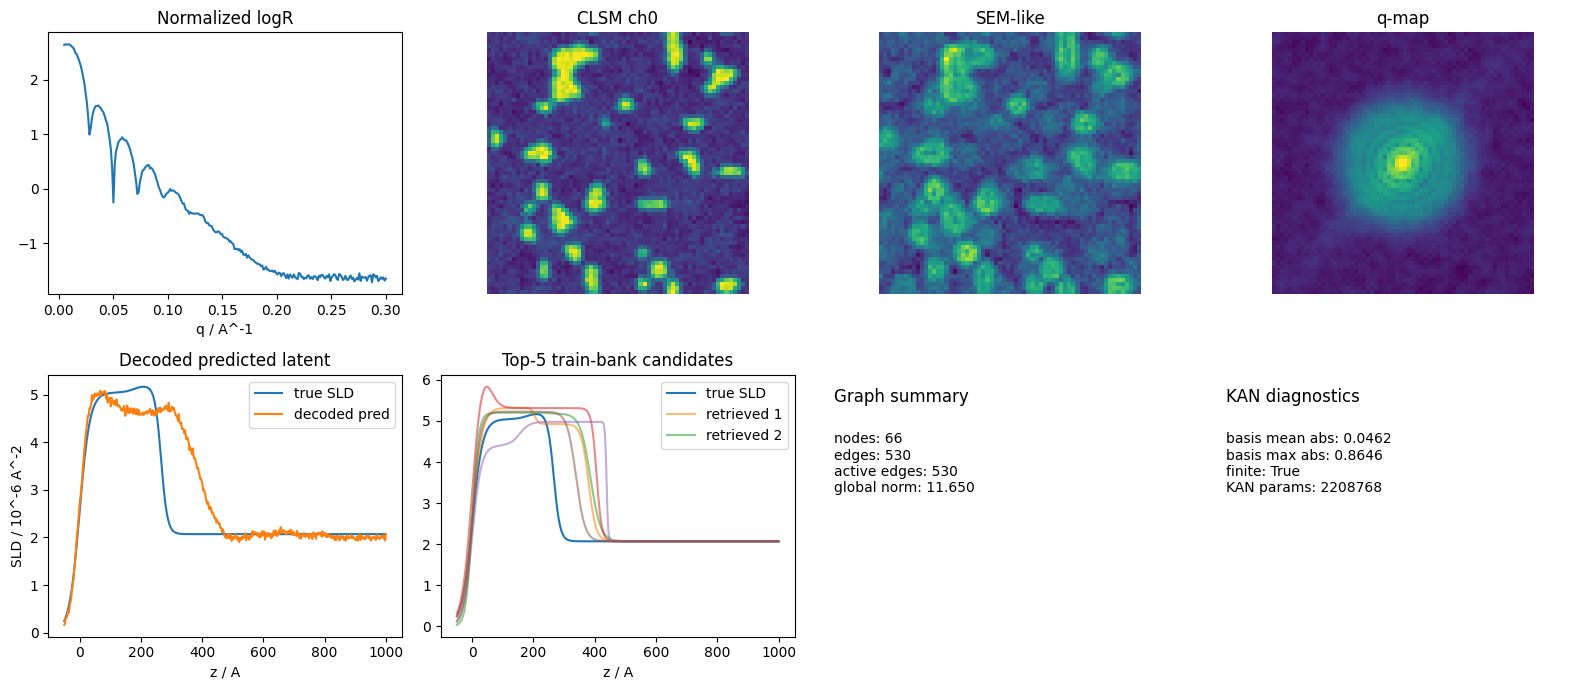

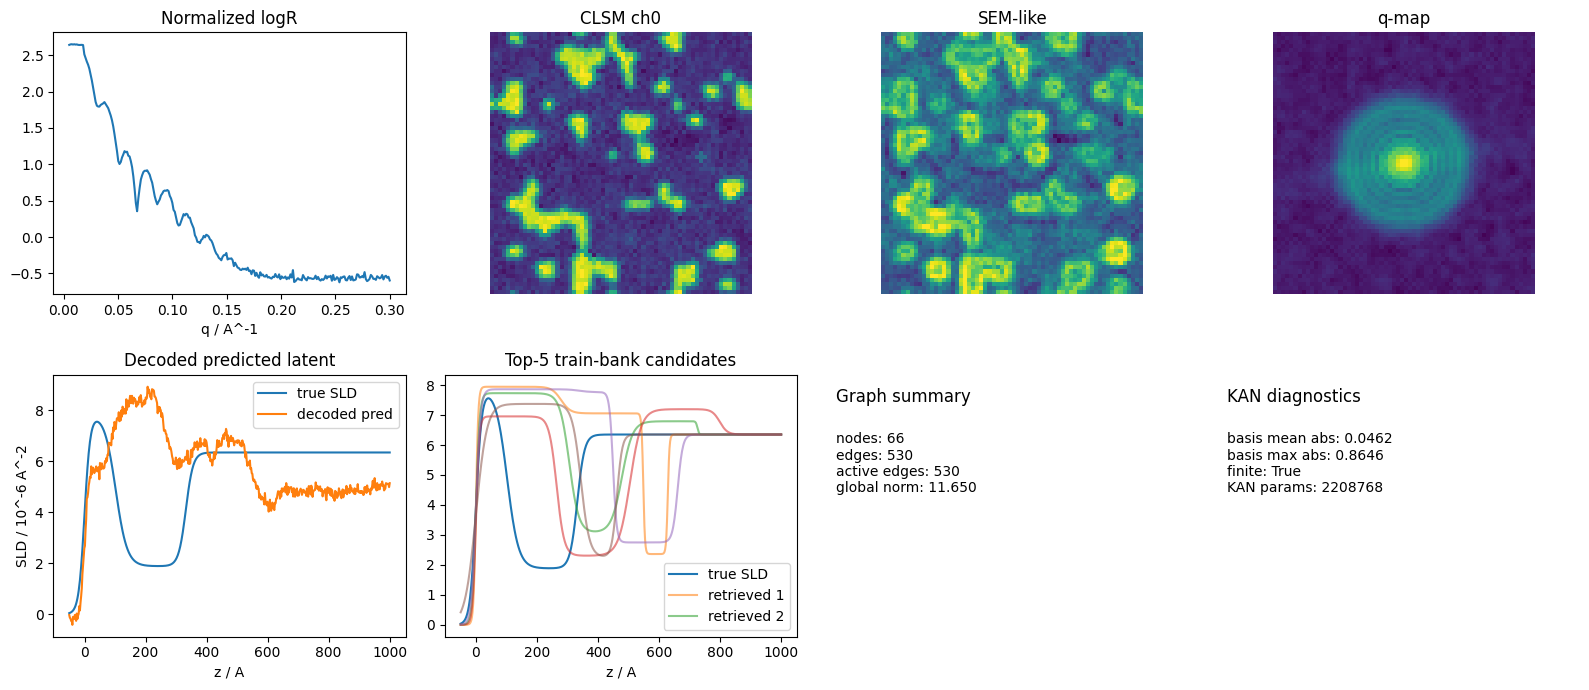

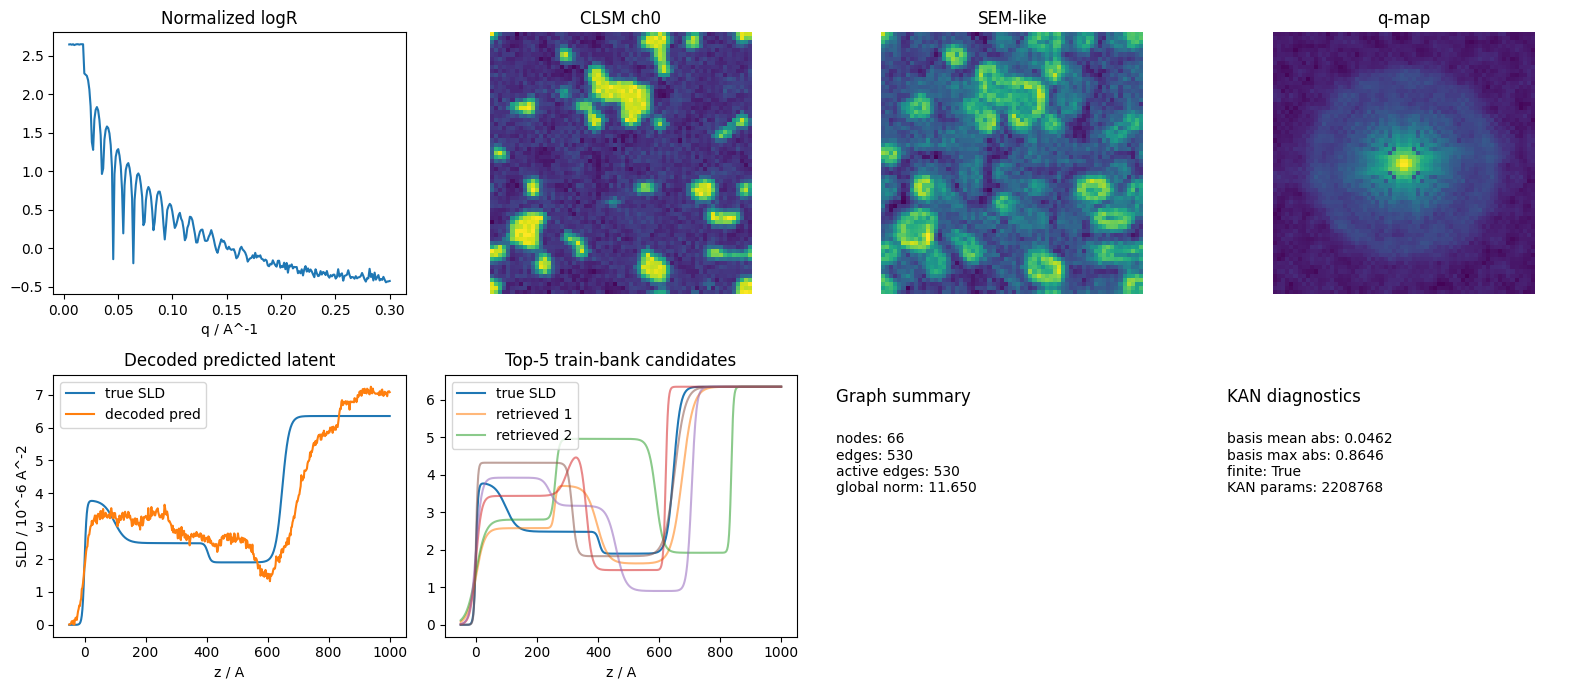

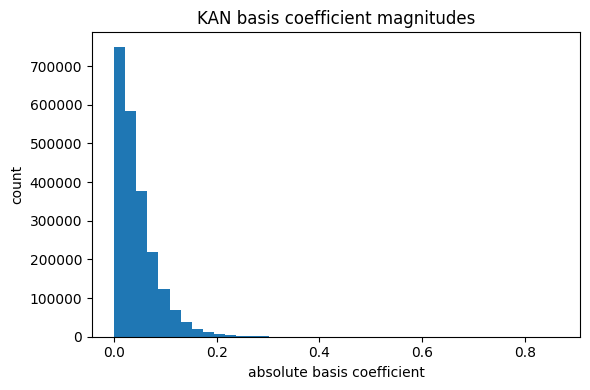

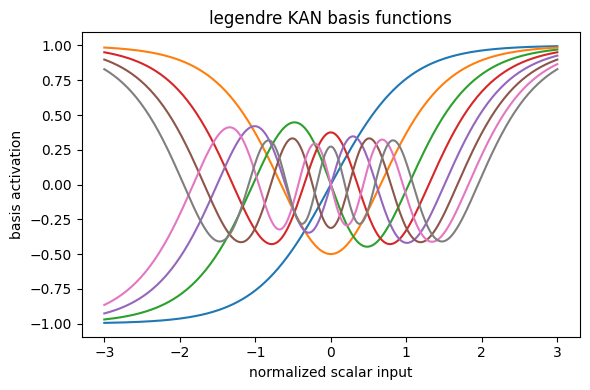

In [50]:
# =====================
# 14. Retrieval examples and graph/KAN diagnostics plots
# =====================

@torch.no_grad()
def get_predictions_for_batch(loader, sample_count=3):
    batch = next(iter(loader))
    batch_dev = to_device(batch, cfg.device)
    pred, diag = model(batch_dev, context_mode="all", graph_mode="full", return_diagnostics=True)
    sim = F.normalize(pred.detach().cpu(), dim=-1) @ F.normalize(train_bank_z, dim=-1).T
    topk = sim.topk(5, dim=1).indices
    return batch, pred, topk, diag

batch, pred, topk, diag = get_predictions_for_batch(test_loader)
num_show = min(3, batch["curve"].shape[0])
for sample in range(num_show):
    true_sld = batch["sld_raw"][sample].numpy() * 1e6
    pred_sld_norm = sld_ae.decoder(pred[sample:sample+1]).squeeze().detach().cpu()
    pred_sld = denormalize_sld_norm(pred_sld_norm, stats).numpy() * 1e6
    candidate_slds = train_bank_sld[topk[sample]].numpy() * 1e6

    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes[0, 0].plot(raw["q"], batch["curve"][sample, 1].numpy())
    axes[0, 0].set_title("Normalized logR")
    axes[0, 0].set_xlabel("q / A^-1")
    axes[0, 1].imshow(batch["clsm"][sample, 0], origin="lower")
    axes[0, 1].set_title("CLSM ch0")
    axes[0, 1].axis("off")
    axes[0, 2].imshow(batch["sem"][sample, 0], origin="lower")
    axes[0, 2].set_title("SEM-like")
    axes[0, 2].axis("off")
    axes[0, 3].imshow(batch["qmap"][sample, 0], origin="lower")
    axes[0, 3].set_title("q-map")
    axes[0, 3].axis("off")

    axes[1, 0].plot(z_grid, true_sld, label="true SLD")
    axes[1, 0].plot(z_grid, pred_sld, label="decoded pred")
    axes[1, 0].set_title("Decoded predicted latent")
    axes[1, 0].set_xlabel("z / A")
    axes[1, 0].set_ylabel("SLD / 10^-6 A^-2")
    axes[1, 0].legend()

    axes[1, 1].plot(z_grid, true_sld, label="true SLD")
    for k in range(candidate_slds.shape[0]):
        axes[1, 1].plot(z_grid, candidate_slds[k], alpha=0.55, label=f"retrieved {k+1}" if k < 2 else None)
    axes[1, 1].set_title("Top-5 train-bank candidates")
    axes[1, 1].set_xlabel("z / A")
    axes[1, 1].legend()

    axes[1, 2].axis("off")
    axes[1, 2].text(0.0, 0.95, "Graph summary", va="top", fontsize=12)
    axes[1, 2].text(0.0, 0.78, f"nodes: {GRAPH_SPEC['num_nodes']}\nedges: {GRAPH_SPEC['edge_index'].shape[1]}\nactive edges: {diag.get('num_active_edges', 'n/a')}\nglobal norm: {diag.get('global_node_norm', float('nan')):.3f}", va="top")

    axes[1, 3].axis("off")
    axes[1, 3].text(0.0, 0.95, "KAN diagnostics", va="top", fontsize=12)
    kd = kan_coefficient_summary(model)
    axes[1, 3].text(0.0, 0.78, f"basis mean abs: {kd['kan_basis_mean_abs']:.4f}\nbasis max abs: {kd['kan_basis_max_abs']:.4f}\nfinite: {kd['kan_basis_finite']}\nKAN params: {kd['kan_basis_param_count']}", va="top")

    plt.tight_layout()
    plt.show()

# KAN coefficient magnitude distribution
coeffs = []
for layer in iter_kan_layers(model):
    coeffs.append(layer.basis_weight.detach().abs().flatten().cpu())
if coeffs:
    coeffs = torch.cat(coeffs).numpy()
    plt.figure(figsize=(6, 4))
    plt.hist(coeffs, bins=40)
    plt.xlabel("absolute basis coefficient")
    plt.ylabel("count")
    plt.title("KAN basis coefficient magnitudes")
    plt.tight_layout()
    plt.show()

# Selected KAN basis functions for the first KAN layer
first_layer = next(iter_kan_layers(model), None)
if first_layer is not None:
    x = torch.linspace(-3, 3, 300)
    with torch.no_grad():
        phi = first_layer.basis_values(x[:, None]).squeeze(1).cpu()
    plt.figure(figsize=(6, 4))
    plt.plot(x.numpy(), phi.numpy())
    plt.xlabel("normalized scalar input")
    plt.ylabel("basis activation")
    plt.title(f"{first_layer.basis} KAN basis functions")
    plt.tight_layout()
    plt.show()


In [51]:
# =====================
# 15. Save outputs and compact result summary
# =====================

OUT_DIR = Path(cfg.output_dir)
OUT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_path = OUT_DIR / "aim_jepa_gnn_kan_checkpoint.pt"
metrics_path = OUT_DIR / "aim_jepa_gnn_kan_metrics_history.csv"
ae_metrics_path = OUT_DIR / "sld_autoencoder_metrics_history.csv"
summary_path = OUT_DIR / "aim_jepa_gnn_kan_context_summary.csv"
graph_ablation_path = OUT_DIR / "aim_jepa_gnn_kan_graph_ablation_summary.csv"
node_ablation_path = OUT_DIR / "aim_jepa_gnn_kan_node_ablation_summary.csv"
kan_diag_path = OUT_DIR / "aim_jepa_gnn_kan_diagnostics.csv"
config_path = OUT_DIR / "config.json"

ckpt = {
    "config": asdict(cfg),
    "stats": stats,
    "graph_spec": {
        "node_type_ids": GRAPH_SPEC["node_type_ids"].cpu(),
        "edge_index": GRAPH_SPEC["edge_index"].cpu(),
        "edge_attr": GRAPH_SPEC["edge_attr"].cpu(),
        "edge_type_ids": GRAPH_SPEC["edge_type_ids"].cpu(),
        "slices": GRAPH_SPEC["slices"],
        "node_types": NODE_TYPES,
        "edge_types": EDGE_TYPES,
    },
    "sld_autoencoder_state_dict": sld_ae.state_dict(),
    "context_model_state_dict": model.state_dict(),
    "ema_graph_teacher_state_dict": None if ema_teacher is None else ema_teacher.state_dict(),
    "mhe_projection_head_state_dict": None if regularizer_projector is None else regularizer_projector.state_dict(),
    "train_idx": train_idx,
    "val_idx": val_idx,
    "test_idx": test_idx,
}
torch.save(ckpt, checkpoint_path)

jepa_history_df.to_csv(metrics_path, index=False)
ae_history_df.to_csv(ae_metrics_path, index=False)
summary_df.to_csv(summary_path, index=False)
graph_ablation_df.to_csv(graph_ablation_path, index=False)
node_ablation_df.to_csv(node_ablation_path, index=False)
kan_diag_df.to_csv(kan_diag_path, index=False)
config_path.write_text(json.dumps(asdict(cfg), indent=2))

print("Saved:")
for p in [checkpoint_path, metrics_path, ae_metrics_path, summary_path, graph_ablation_path, node_ablation_path, kan_diag_path, config_path]:
    print(" ", p)

final_val = summary_df[(summary_df["split"] == "val") & (summary_df["context_mode"] == "all")].iloc[0]
final_test = summary_df[(summary_df["split"] == "test") & (summary_df["context_mode"] == "all")].iloc[0]
summary_keys = [
    "loss", "cos", "recall_at_1", "recall_at_5", "recall_at_10",
    "decoder_sld_mae_uA2", "trainbank_top5_oracle_sld_mae_uA2",
    "pred_std", "target_std", "collapse_warning",
    "mhe_loss", "mhe_trace_loss", "mhe_trace", "mhe_participation_ratio", "mhe_condition_number",
    "pred_mhe_loss", "pred_mhe_trace_loss", "pred_mhe_trace", "pred_mhe_participation_ratio", "pred_mhe_condition_number",
    "masked_loss", "masked_node_cos", "masked_node_mse", "masked_pred_std", "masked_target_std",
]
result_summary = pd.DataFrame([
    {"split": "val", **{k: final_val[k] for k in summary_keys if k in final_val}},
    {"split": "test", **{k: final_test[k] for k in summary_keys if k in final_test}},
])
print("Compact all-context result summary:")
display(result_summary)


Saved:
  /content/aim_jepa_gnn_kan_outputs/aim_jepa_gnn_kan_checkpoint.pt
  /content/aim_jepa_gnn_kan_outputs/aim_jepa_gnn_kan_metrics_history.csv
  /content/aim_jepa_gnn_kan_outputs/sld_autoencoder_metrics_history.csv
  /content/aim_jepa_gnn_kan_outputs/aim_jepa_gnn_kan_context_summary.csv
  /content/aim_jepa_gnn_kan_outputs/aim_jepa_gnn_kan_graph_ablation_summary.csv
  /content/aim_jepa_gnn_kan_outputs/aim_jepa_gnn_kan_node_ablation_summary.csv
  /content/aim_jepa_gnn_kan_outputs/aim_jepa_gnn_kan_diagnostics.csv
  /content/aim_jepa_gnn_kan_outputs/config.json
Compact all-context result summary:


,split,loss,cos,recall_at_1,recall_at_5,recall_at_10,decoder_sld_mae_uA2,trainbank_top5_oracle_sld_mae_uA2,pred_std,target_std,...,mhe_trace,mhe_participation_ratio,mhe_condition_number,pred_mhe_loss,pred_mhe_trace_loss,masked_loss,masked_node_cos,masked_node_mse,masked_pred_std,masked_target_std
0,val,1.044524,0.800332,0.197333,0.576,0.744000,0.694725,0.437063,0.095154,0.086242,...,14.674162,17.841018,69.364097,0.0,0.0,0.000249,0.880659,0.001865,0.772929,0.739942
1,test,0.987592,0.796758,0.194667,0.564,0.738667,0.700552,0.427990,0.095411,0.086235,...,14.761673,18.151589,65.266371,0.0,0.0,0.000274,0.870045,0.002031,0.780494,0.755066


## How to interpret this synthetic POC

A useful run should show validation latent cosine above random alignment, Recall@5 above the random split baseline, nonzero predicted latent standard deviation, finite KAN coefficients, and graph/node ablations that change performance in plausible directions.

For proposal language, treat this as a controlled method benchmark only. It supports graph-based latent structural prediction and retrieval on synthetic data. It does not establish biological validation, real AIM-Bio performance, or KAN interpretability beyond the explicit basis-coefficient diagnostics plotted here.

The current default also includes a masked-node JEPA objective: the student context graph receives hidden q-sector/image/qmap/metadata nodes, while an EMA graph teacher encodes the unmasked observed-modality graph. This auxiliary branch does not use the SLD target and is intended to test missing-node/missing-modality latent prediction in addition to frozen SLD-latent prediction.

KAN layers now use configurable basis expansions. The current default is Legendre polynomial KAN (`cfg.kan_basis = "legendre"`), because it has been the strongest recent synthetic benchmark setting in this notebook. Available options are `fourier`, `chebyshev`, `legendre`, `hermite`, `laguerre`, `gegenbauer`, and `rbf`. Use the same loss weights for the first controlled basis comparison; if a basis collapses, tune `lr_jepa`, `lambda_var`, `lambda_sigreg`, `lambda_infonce`, and `num_basis` for that basis.


Multifractal entropy regularization is available through `cfg.lambda_mhe` and `cfg.lambda_pred_mhe`. The entropy exponents are `beta = cfg.mhe_mf_d * q` from `cfg.mhe_q_values`, unless explicit values are supplied in `cfg.mhe_betas`. The current checked-in configuration uses MHE replacement (`cfg.lambda_sigreg = 0.0`, `cfg.lambda_mhe = 0.10`, `cfg.lambda_trace = 0.05`). For a SIGReg baseline use `cfg.lambda_sigreg = 0.05` and `cfg.lambda_mhe = 0.0`; for an add-on ablation use `cfg.lambda_mhe = 0.005` with `cfg.lambda_sigreg = 0.05`. Predictive-spectrum MHE uses `cfg.lambda_pred_mhe` and compares the predictable cross-spectrum between `z_pred` and stop-gradient `z_target`.
